# Buckets 1-4 Research Backtest

Fast bucket-level research and portfolio-level validation for the ETF long/short strategy.

This notebook intentionally keeps only the mechanics needed to answer:

- Which buckets work independently?
- Which small parameter changes improve CAGR / risk-adjusted return?
- How does the configured full book perform after sleeve allocation, caps, listing gates, and covariance adjustment?

Important bias note: the default mode uses the current screened universe and current production sizing features applied historically, with hard listing/inception gates from actual price history. That is useful for fast research, but it is not a true point-in-time historical sizing simulation. The `point_in_time_sizing` switch is reserved for a future dated-snapshot path.

## 1. Setup / Config

Top-level switches live in `EXP`. The default run is fast and static: current sizing data is applied historically, while actual listing/inception dates prevent pre-launch trading. Set `point_in_time_sizing=True` only after adding a dated screener snapshot loader.

**Capital path:** `initial_capital_usd` and `capital_usd` are the same seed (default \$625k from YAML). The simulators compound NAV; stock sleeves re-scale toward `NAV × gross_leverage` on each rebalance. See **section 4 (Shared Helpers)** for details and Bucket 3 weekly scaling.



In [53]:
import copy
import itertools
import json
import math
import os
import pickle
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format

TRADING_DAYS = 252


def norm_sym(x: str) -> str:
    return str(x).strip().upper().replace(".", "-")


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in (here, here.parent, *here.parents):
        if (p / "config" / "strategy_config.yml").exists() and (p / "scripts" / "gtp_sizing_mirror.py").exists():
            return p
    raise FileNotFoundError("Could not find repo root with config/strategy_config.yml and scripts/gtp_sizing_mirror.py")


REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
DATA_DIR = REPO_ROOT / "data"
CACHE_DIR = NOTEBOOK_DIR / ".cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CONFIG_PATH = REPO_ROOT / "config" / "strategy_config.yml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    STRATEGY_CFG = yaml.safe_load(f) or {}

sleeves_cfg = (STRATEGY_CFG.get("portfolio") or {}).get("sleeves") or {}
strategy_cfg = STRATEGY_CFG.get("strategy") or {}
_INITIAL_CAPITAL_USD = float(strategy_cfg.get("capital_usd", 625_000))

EXP = {
    "start_date": "2023-01-01",
    "end_date": None,
    # NAV(0) = seed for backtest; also mirror sizing anchor. Compounded in sim; see Shared Helpers note.
    "capital_usd": _INITIAL_CAPITAL_USD,
    "initial_capital_usd": _INITIAL_CAPITAL_USD,
    "gross_leverage": float(strategy_cfg.get("gross_leverage", 4.0)),
    "rebalance_freq": "W-FRI",
    # Standalone Bucket 4 sim default (see ``_resolve_sim_rebalance_freq``). Combined book uses ``rebalance_freq`` only.
    "rebalance_freq_bucket_4": "W-FRI",
    "run_buckets": [1, 2, 3, 4],
    "run_combined": True,
    "use_covariance": True,
    "book_level_covariance": True,
    "point_in_time_sizing": False,
    "static_today_sizing": True,
    "download_missing_prices": True,
    "price_cache_path": str(CACHE_DIR / "buckets14_prices.pkl"),
    "v6_b4_cache_path": str(NOTEBOOK_DIR / "v6_b4_gtp_cache.pkl"),
    "v6_b4_cache_rebuild": False,
    # When no pickle exists (or load fails), run Bucket_4_Backtest.ipynb bootstrap once and write the cache.
    "v6_b4_allow_auto_bootstrap": True,
    # Buckets 2 and 4 start only once each sleeve has enough listed/live pairs.
    "bucket_start_min_active_pairs": {2: 8, 4: 8},
    # Bucket 4 backtest only: True = time-varying h from v6_opt2_h_daily_map; False = static hedge from ``partial_hedge_ratio`` in config (GTP mirror legs).
    "b4_dynamic_hedge": True,
    "max_grid_rows_per_bucket": 6,
    "debug": False,
    # Bucket 4 notebook-only: drop these ETF inverse rows when sizing B4 / combined-book screen.
    "bucket_4_etf_blacklist_extra": ["SCO"],
    # Splice these inverse ETFs from SCREENED if filters would omit them entirely.
    "bucket_4_etf_always_include": ["UVIX"],
    # In Bucket 4, treat short **stock** hedge legs as financed at 0% (no GENERAL stock borrow); inverse ETF shorts still pay ``BORROW_BY_ETF``. See `_borrow_drag_daily`.
    "bucket_4_zero_underlying_borrow": True,
    # Half-spread on turnover: supplemental ``estimated_tcost_usd``; NAV is net of ``stock_sim_*`` below.
    "tcost_half_spread_bps": float(strategy_cfg.get("tcost_half_spread_bps", 5.0)),
    "stock_sim_fee_bps": 1.0,
    "stock_sim_slippage_bps": 20.0,
    # Scale flow-program weekly short deployment with compounded NAV (~constant % of equity vs fixed USD).
    "bucket3_scale_weekly_with_nav": True,
}

if EXP["point_in_time_sizing"]:
    raise NotImplementedError("Point-in-time sizing needs dated screener snapshots; default notebook is static-today sizing with inception gates.")

print(f"Repo root: {REPO_ROOT}")
print(f"Initial NAV: ${EXP['initial_capital_usd']:,.0f} | target gross/leverage anchor: ≈ NAV × {EXP['gross_leverage']:.2f} on rebalance dates (see Shared Helpers)")
print("Sleeve weights:", {k: v.get("target_weight") for k, v in sleeves_cfg.items() if isinstance(v, dict)})


Repo root: C:\Users\werdn\Documents\Investing\ls-algo
Initial NAV: $625,000 | target gross/leverage anchor: ≈ NAV × 4.00 on rebalance dates (see Shared Helpers)
Sleeve weights: {'core_leveraged': 0.45, 'whitelist_stock': 0.5, 'inverse_decay_bucket4': 0.05, 'flow_program': None}


## 2. Data Loading

Loads the current screened universe, cached total-return-like adjusted close series, borrow columns from the screener, and pair inception dates from actual ETF/underlying price overlap. Every simulator filters `inception <= date`, so names such as FIYY cannot trade before valid market data exists.

In [54]:
SCREENED_PATH = REPO_ROOT / (STRATEGY_CFG.get("paths") or {}).get("screened_csv", "data/etf_screened_today.csv")
if not SCREENED_PATH.exists():
    raise FileNotFoundError(SCREENED_PATH)

SCREENED_RAW = pd.read_csv(SCREENED_PATH)
SCREENED = SCREENED_RAW.copy()
for c in ("ETF", "Underlying"):
    SCREENED[c] = SCREENED[c].astype(str).map(norm_sym)
for c in ["Beta", "borrow_current", "borrow_fee_annual", "net_decay_annual", "net_edge_p50_annual", "bucket4_net_edge_annual", "vol_underlying_annual", "shares_available", "borrow_price_ref", "underlying_borrow_annual"]:
    if c in SCREENED.columns:
        SCREENED[c] = pd.to_numeric(SCREENED[c], errors="coerce")
for c in ["purgatory", "is_yieldboost", "inverse_shortable", "strategy_blacklisted"]:
    if c in SCREENED.columns:
        SCREENED[c] = SCREENED[c].fillna(False).astype(bool)

BLACKLIST = {norm_sym(x) for x in (strategy_cfg.get("blacklist") or [])}
SCREENED = SCREENED[(~SCREENED["ETF"].isin(BLACKLIST)) & (~SCREENED["Underlying"].isin(BLACKLIST))].copy()

FLOW_ETFS = {
    norm_sym(x)
    for x in (((sleeves_cfg.get("flow_program") or {}).get("universe") or {}).get("shorts") or [])
}

CANDIDATES = (
    SCREENED[["ETF", "Underlying", "Beta"]]
    .dropna(subset=["ETF", "Underlying", "Beta"])
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
CANDIDATES = [(norm_sym(e), norm_sym(u), float(b)) for e, u, b in CANDIDATES]
ALL_TICKERS = sorted({"SPY"} | {e for e, _, _ in CANDIDATES} | {u for _, u, _ in CANDIDATES})


def _normalize_price_index(s: pd.Series) -> pd.Series:
    s = pd.Series(s).dropna().astype(float).sort_index()
    ix = pd.to_datetime(s.index, errors="coerce")
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("UTC").tz_localize(None)
    s.index = pd.DatetimeIndex(ix).normalize()
    s = s.loc[s.index.notna()]
    return s[~s.index.duplicated(keep="last")]


def load_price_cache(path: Path) -> dict[str, pd.Series]:
    if not path.exists():
        return {}
    with open(path, "rb") as f:
        obj = pickle.load(f)
    out = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            try:
                out[norm_sym(k)] = _normalize_price_index(v)
            except Exception:
                pass
    return out


def save_price_cache(path: Path, prices: dict[str, pd.Series]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(prices, f, protocol=pickle.HIGHEST_PROTOCOL)


def fetch_prices_yf(tickers: list[str], *, cache_path: Path, download_missing: bool = True) -> dict[str, pd.Series]:
    prices = load_price_cache(cache_path)
    missing = [t for t in tickers if t not in prices or len(prices[t]) < 20]
    if missing and download_missing:
        import yfinance as yf
        from concurrent.futures import ThreadPoolExecutor, as_completed

        def _one(t: str):
            try:
                df = yf.Ticker(t).history(period="max", auto_adjust=True, actions=False)
                if df is None or df.empty or "Close" not in df.columns:
                    return t, None
                return t, _normalize_price_index(df["Close"])
            except Exception:
                return t, None

        print(f"Fetching {len(missing)} missing price series...")
        t0 = time.time()
        with ThreadPoolExecutor(max_workers=8) as ex:
            futs = {ex.submit(_one, t): t for t in missing}
            for i, fut in enumerate(as_completed(futs), 1):
                t, s = fut.result()
                if s is not None and len(s) >= 20:
                    prices[norm_sym(t)] = s
                if i % 50 == 0:
                    print(f"  {i}/{len(missing)} [{time.time() - t0:.0f}s]")
        save_price_cache(cache_path, prices)
    return prices


PRICES = fetch_prices_yf(
    ALL_TICKERS,
    cache_path=Path(EXP["price_cache_path"]),
    download_missing=bool(EXP["download_missing_prices"]),
)

start_ts = pd.Timestamp(EXP["start_date"])
end_ts = pd.Timestamp(EXP["end_date"]) if EXP["end_date"] else None
if "SPY" in PRICES:
    TRADING_DAYS_INDEX = PRICES["SPY"].loc[PRICES["SPY"].index >= start_ts].index
else:
    any_ix = sorted(set().union(*(s.index for s in PRICES.values())))
    TRADING_DAYS_INDEX = pd.DatetimeIndex([d for d in any_ix if d >= start_ts])
if end_ts is not None:
    TRADING_DAYS_INDEX = TRADING_DAYS_INDEX[TRADING_DAYS_INDEX <= end_ts]

INCEPTION: dict[tuple[str, str], pd.Timestamp] = {}
for e, u, beta in CANDIDATES:
    se, su = PRICES.get(e), PRICES.get(u)
    if se is None or su is None or se.empty or su.empty:
        continue
    first = max(pd.Timestamp(se.index[0]), pd.Timestamp(su.index[0]))
    if e in FLOW_ETFS:
        first = max(first, pd.Timestamp(EXP["start_date"]))
    INCEPTION[(e, u)] = first

TRADABLE_PAIRS = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNDERLYING_PRICES = pd.DataFrame({u: PRICES[u] for _, u, _ in TRADABLE_PAIRS if u in PRICES}).sort_index()
UNDERLYING_RETURNS = np.log(UNDERLYING_PRICES.replace(0, np.nan)).diff().dropna(how="all")

from scripts.gtp_dashboard_borrow import load_dashboard_borrow_avg_annual

DASHBOARD_BORROW_AVG, DASHBOARD_BORROW_SOURCE = load_dashboard_borrow_avg_annual()
if DASHBOARD_BORROW_AVG:
    _dash_borrow = SCREENED["ETF"].map(lambda s: DASHBOARD_BORROW_AVG.get(norm_sym(s), np.nan))
    _dash_hit = int(_dash_borrow.notna().sum())
    for _col in ("borrow_current", "borrow_fee_annual", "borrow_for_net_annual", "borrow_avg_annual"):
        if _col not in SCREENED.columns:
            SCREENED[_col] = np.nan
        SCREENED[_col] = _dash_borrow.where(_dash_borrow.notna(), pd.to_numeric(SCREENED[_col], errors="coerce"))
    print(f"[borrow] using etf-dashboard borrow_avg_annual for {_dash_hit}/{len(SCREENED)} screened rows from {DASHBOARD_BORROW_SOURCE}")
else:
    print("[borrow] etf-dashboard borrow_avg_annual unavailable; falling back to screener borrow_current/borrow_fee_annual")

BORROW_BY_ETF = {}
for _, r in SCREENED.iterrows():
    e = norm_sym(r["ETF"])
    b = r.get("borrow_avg_annual", np.nan)
    if not np.isfinite(b):
        b = r.get("borrow_current", np.nan)
    if not np.isfinite(b):
        b = r.get("borrow_fee_annual", np.nan)
    if np.isfinite(b):
        BORROW_BY_ETF[e] = float(max(0.0, b))
UNDERLYING_BORROW = {
    norm_sym(r["Underlying"]): float(max(0.0, r.get("underlying_borrow_annual", 0.0)))
    for _, r in SCREENED.iterrows()
    if np.isfinite(r.get("underlying_borrow_annual", np.nan))
}

b4_screened_etfs = set(SCREENED.loc[(SCREENED.get("Beta", 0) < 0) & (SCREENED.get("inverse_shortable", False).astype(bool)), "ETF"])
print(f"Screened rows: {len(SCREENED):,} | tradable pairs with overlapping prices: {len(TRADABLE_PAIRS):,}/{len(CANDIDATES):,}")
print(f"Underlying return frame: {UNDERLYING_RETURNS.shape[1]} cols x {UNDERLYING_RETURNS.shape[0]} rows")
print(f"Bucket 4 inverse/shortable ETFs from screened CSV: {len(b4_screened_etfs)}")
if "FIYY" in {e for e, _, _ in TRADABLE_PAIRS}:
    fiyy_dates = [INCEPTION[(e, u)] for e, u, _ in TRADABLE_PAIRS if e == "FIYY"]
    print("FIYY first tradable date:", min(fiyy_dates).date())

Fetching 19 missing price series...
[borrow] using etf-dashboard borrow_avg_annual for 416/424 screened rows from ..\..\etf-dashboard\data\dashboard_data.json
Screened rows: 424 | tradable pairs with overlapping prices: 401/420
Underlying return frame: 211 cols x 16194 rows
Bucket 4 inverse/shortable ETFs from screened CSV: 60
FIYY first tradable date: 2018-03-15


## 3. Bucket 4 v6 Cache

Bucket 4 sizing uses the v6 portfolio-style override. If `notebooks/v6_b4_gtp_cache.pkl` exists, it loads in seconds. If it is missing, the notebook **auto-bootstraps** from `Bucket_4_Backtest.ipynb` once (slow) and writes the pickle. Set `EXP["v6_b4_cache_rebuild"] = True` to force a refresh. Set `EXP["v6_b4_allow_auto_bootstrap"] = False` to skip the slow path and require a pre-built cache.

In [55]:
from scripts.v6_b4_pf_weights import V6PfParams, compute_v6_b4_pf_weight_dict

V6_GLOBALS_READY = False
V6_B4_WEIGHT_OVERRIDE = None
V6_B4_DIAG = pd.DataFrame()
V6_B4_META = {}


def _v6_backtest_borrow_map(symbols: list[str]) -> dict[str, float]:
    """Borrow callback for v6 sizing; prefer etf-dashboard average borrow used by this backtest."""
    snap = globals().get("_V6_IBKR_BORROW_SNAPSHOT")
    out = {}
    for s in symbols:
        k = norm_sym(s)
        v = BORROW_BY_ETF.get(k)
        if v is None and isinstance(snap, dict):
            v = snap.get(k)
        if v is not None and np.isfinite(float(v)) and float(v) >= 0:
            out[k] = float(v)
    return out


_v6_saved_get_ibkr_borrow_map = _v6_backtest_borrow_map


def load_or_build_v6_globals() -> bool:
    cache_path = Path(EXP["v6_b4_cache_path"])
    force_rebuild = bool(EXP.get("v6_b4_cache_rebuild", False))
    allow_bootstrap = bool(EXP.get("v6_b4_allow_auto_bootstrap", True))

    def _apply_bundle(bundle: dict) -> bool:
        for k in ("_V6_PAIR_CACHE", "v6_opt2_h_daily_map", "V6_OPT2_H_BASE", "v6_opt2_rebal_index", "_V6_IBKR_BORROW_SNAPSHOT"):
            if k in bundle and bundle[k] is not None:
                globals()[k] = bundle[k]
        globals()["get_ibkr_borrow_map"] = _v6_saved_get_ibkr_borrow_map
        return all(globals().get(k) is not None for k in ("_V6_PAIR_CACHE", "v6_opt2_h_daily_map", "V6_OPT2_H_BASE"))

    if cache_path.exists() and not force_rebuild:
        try:
            with open(cache_path, "rb") as f:
                bundle = pickle.load(f)
            if _apply_bundle(bundle):
                print(f"[v6] loaded cache: {cache_path}")
                return True
            print("[v6] cache file present but incomplete; will rebuild.")
        except Exception as _e:
            print(f"[v6] cache load failed ({_e}); will rebuild.")

    if not allow_bootstrap and not force_rebuild:
        print(
            f"[v6] no usable cache at {cache_path} and auto-bootstrap is off. "
            "Set EXP['v6_b4_allow_auto_bootstrap']=True once, or EXP['v6_b4_cache_rebuild']=True with a valid env."
        )
        return False

    from scripts.v6_bucket4_bootstrap_from_nb import ensure_v6_bucket4_globals_from_notebook

    print("[v6] bootstrapping from Bucket_4_Backtest.ipynb (slow first run)...")
    ensure_v6_bucket4_globals_from_notebook(globals(), repo_root=REPO_ROOT, screened_csv=SCREENED_PATH)
    globals()["get_ibkr_borrow_map"] = _v6_backtest_borrow_map
    etfs = {str(k[0]) for k, c in globals()["_V6_PAIR_CACHE"].items() if "skip_reason" not in c}
    etfs.add("UVIX")
    snap_fn = _v6_backtest_borrow_map
    bundle = {
        "version": 1,
        "_V6_PAIR_CACHE": globals()["_V6_PAIR_CACHE"],
        "v6_opt2_h_daily_map": globals()["v6_opt2_h_daily_map"],
        "V6_OPT2_H_BASE": float(globals()["V6_OPT2_H_BASE"]),
        "v6_opt2_rebal_index": globals().get("v6_opt2_rebal_index"),
        "_V6_IBKR_BORROW_SNAPSHOT": dict(snap_fn(sorted(etfs))) if callable(snap_fn) else {},
    }
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with open(cache_path, "wb") as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[v6] rebuilt and cached: {cache_path}")
    return True


V6_GLOBALS_READY = load_or_build_v6_globals()


def compute_b4_v6_override(params: dict | None = None) -> tuple[dict[tuple[str, str], float] | None, pd.DataFrame, dict]:
    if not V6_GLOBALS_READY:
        raise RuntimeError(
            "Bucket 4 v6 globals are unavailable. Re-run the v6 cache cell, or set EXP['v6_b4_allow_auto_bootstrap']=True "
            "and ensure scripts/v6_bucket4_bootstrap_from_nb.py can exec notebooks/Bucket_4_Backtest.ipynb."
        )
    p = V6PfParams(**{k: v for k, v in (params or {}).items() if k in V6PfParams.__dataclass_fields__})
    closes_broad = globals().get("closes_broad")
    if not isinstance(closes_broad, pd.DataFrame):
        # Cache bundles from the old notebook may not include closes_broad. The helper can still use pair-level history.
        closes_broad = None
    weights, diag, meta = compute_v6_b4_pf_weight_dict(
        pair_cache=globals()["_V6_PAIR_CACHE"],
        v6_opt2_h_daily_map=globals()["v6_opt2_h_daily_map"],
        screened_csv=str(SCREENED_PATH),
        closes_broad=closes_broad,
        norm_sym=norm_sym,
        get_ibkr_borrow_map=_v6_backtest_borrow_map,
        opt2_h_base=float(globals()["V6_OPT2_H_BASE"]),
        params=p,
    )
    return weights, diag, meta


if V6_GLOBALS_READY:
    V6_B4_WEIGHT_OVERRIDE, V6_B4_DIAG, V6_B4_META = compute_b4_v6_override()
    print(f"[v6] B4 override pairs={len(V6_B4_WEIGHT_OVERRIDE)} | start={V6_B4_META.get('start_sim')} | decay={V6_B4_META.get('decay_src_col')}")

[v6] loaded cache: C:\Users\werdn\Documents\Investing\ls-algo\notebooks\v6_b4_gtp_cache.pkl
[v6] B4 override pairs=11 | start=2025-10-07 00:00:00 | decay=net_edge_p50_annual


## 4. Shared Helpers

These helpers intentionally centralize the mechanics that affect returns and implementation realism: eligibility gates, GTP mirror sizing, v6 Bucket 4 override, per-sleeve caps, covariance adjustment, listing gates, long/short leg construction, borrow drag, turnover, and compact reporting.

### Capital path and gross leverage

- **`initial_capital_usd` / `capital_usd`**: NAV at \(t = 0\) (defaults to \$625k from `strategy.capital_usd` in YAML).
- **Compounding**: Each day NAV is marked with P\&L and borrow; on rebalance days, **`simulate_sized_pairs`** and **`simulate_bucket3`** deduct commission + slippage on traded $\sum|\Delta|$ notional (bps rates **stock_sim_fee_bps** and **stock_sim_slippage_bps** on **EXP**). **`simulate_sized_pairs`** does **not** hold gross exposure fixed in dollars.
- **Target \(\approx 4\times\) gross**: On every rebalance, pair notionals are re-scaled so total gross \(\sum |{\rm legs}|\approx {\rm NAV}\times\texttt{gross\_leverage}\). Between rebalances, gross drifts as prices move—that is intentional (no daily de-lever unless you shorten `rebalance_freq`).
- **Sizing snapshot**: Mirror sizing still reads `capital_usd` for **shape/caps relative to today's book**, but simulated weights are anchored to **each rebalance day's compounded NAV**.
- **Bucket 3**: When `bucket3_scale_weekly_with_nav` is enabled, weekly short adds scale with compounded NAV around the YAML/base weekly budget at \(t=0\).


- **Standalone Bucket 4** uses **`EXP["rebalance_freq_bucket_4"]`** (default **`W-FRI`**) when the grid does not supply `rebalance_freq`. Use **`2W-FRI`** for fortnightly B4. The combined stock simulation still uses **`EXP["rebalance_freq"]`** for **all sleeves** together (single re-date calendar).


In [ ]:
# Reload so edits to generate_trade_plan.py always apply (Jupyter keeps stale modules in sys.modules).
import importlib

import generate_trade_plan as _gtp_live

importlib.reload(_gtp_live)
import scripts.gtp_sizing_mirror as _gsm_live

importlib.reload(_gsm_live)

from generate_trade_plan import (
    _norm_sym as gtp_norm,
    apply_covariance_balance,
    apply_gross_sizing_book_caps,
)
from scripts.gtp_sizing_mirror import mirror_generate_trade_plan_sizing

SLEEVE_BY_BUCKET = {
    1: "core_leveraged",
    2: "whitelist_stock",        # Production key; notebook labels this as yieldBOOST.
    4: "inverse_decay_bucket4",
}
BUCKET_LABEL = {1: "Bucket 1", 2: "Bucket 2 yieldBOOST", 3: "Bucket 3 flow", 4: "Bucket 4 inverse v6"}
SLEEVE_START_MIN_ACTIVE_PAIRS = {
    SLEEVE_BY_BUCKET[int(bucket)]: int(min_pairs)
    for bucket, min_pairs in (EXP.get("bucket_start_min_active_pairs") or {}).items()
    if int(bucket) in SLEEVE_BY_BUCKET and int(min_pairs) > 1
}


def _deepcopy_cfg() -> dict:
    return copy.deepcopy(STRATEGY_CFG)


def _set_sleeve_weight(cfg: dict, sleeve: str, weight: float) -> None:
    s = cfg.setdefault("portfolio", {}).setdefault("sleeves", {}).setdefault(sleeve, {})
    s["target_weight"] = float(weight)


def prepare_sizing_cfg(bucket: int | str, params: dict | None = None, *, combined: bool = False) -> dict:
    params = params or {}
    cfg = _deepcopy_cfg()
    cfg.setdefault("strategy", {})["capital_usd"] = float(EXP["capital_usd"])
    cfg["strategy"]["gross_leverage"] = float(EXP["gross_leverage"])

    # Use configured production caps; only override through explicit research params.
    caps = cfg["strategy"].setdefault("gross_sizing_caps", copy.deepcopy(strategy_cfg.get("gross_sizing_caps") or {}))
    caps["enabled"] = bool(caps.get("enabled", True))
    per_sleeve = caps.setdefault("per_sleeve", {})

    if params.get("max_name_weight") is not None:
        sleeve = SLEEVE_BY_BUCKET.get(bucket)
        if sleeve:
            cfg.setdefault("portfolio", {}).setdefault("sleeves", {}).setdefault(sleeve, {}).setdefault("weighting", {})["max_name_weight"] = float(params["max_name_weight"])
            per_sleeve.setdefault(sleeve, {})["max_pair_weight"] = float(params["max_name_weight"])
    if params.get("max_underlying_weight") is not None:
        sleeve = SLEEVE_BY_BUCKET.get(bucket)
        if sleeve:
            per_sleeve.setdefault(sleeve, {})["max_underlying_weight"] = float(params["max_underlying_weight"])
    for _cap_key in ("missing_shares_cap", "short_avail_use_pct", "aum_use_pct", "median_daily_volume_use_pct"):
        if params.get(_cap_key) is not None:
            caps[_cap_key] = float(params[_cap_key])

    cov_base = copy.deepcopy(strategy_cfg.get("covariance_balance") or {})
    cov_base.update({
        "enabled": bool(EXP["use_covariance"] and params.get("use_covariance", True)),
        "lookback_days": int(params.get("cov_lookback_days", cov_base.get("lookback_days", 252) or 252)),
        "min_obs": int(params.get("cov_min_obs", cov_base.get("min_obs", 60) or 60)),
        "shrink": float(params.get("cov_shrink", cov_base.get("shrink", 0.35) or 0.35)),
        "penalty_strength": float(params.get("cov_penalty", cov_base.get("penalty_strength", 0.85) or 0.85)),
        "max_relative_shift": float(params.get("cov_max_relative_shift", cov_base.get("max_relative_shift", 0.50) or 0.50)),
    })
    cfg["strategy"]["covariance_balance"] = cov_base

    sleeves = cfg.setdefault("portfolio", {}).setdefault("sleeves", {})
    for sleeve_key in ("core_leveraged", "whitelist_stock", "inverse_decay_bucket4"):
        sleeves.setdefault(sleeve_key, {}).setdefault("weighting", {})
        w = sleeves[sleeve_key]["weighting"]
        for k in ("borrow_aversion", "eq_blend", "score_concavity_p"):
            if params.get(k) is not None:
                w[k] = float(params[k])

    if params.get("min_net_edge") is not None:
        floor = float(params["min_net_edge"])
        if bucket == 1:
            sleeves["core_leveraged"].setdefault("rules", {})["min_net_decay_annual"] = floor
        elif bucket == 4:
            sleeves["inverse_decay_bucket4"].setdefault("rules", {})["min_net_edge_annual"] = floor

    if params.get("borrow_cap") is not None:
        cap = float(params["borrow_cap"])
        if bucket == 1:
            cfg.setdefault("screener", {}).setdefault("per_bucket", {}).setdefault("bucket_1", {})["hard_borrow_cap"] = cap
        elif bucket == 2:
            cfg.setdefault("screener", {}).setdefault("per_bucket", {}).setdefault("bucket_2", {})["hard_borrow_cap"] = cap
        elif bucket == 4:
            sleeves["inverse_decay_bucket4"].setdefault("rules", {})["bucket4_borrow_cap"] = cap
            sleeves["inverse_decay_bucket4"].setdefault("rules", {})["hard_borrow_cap"] = cap

    if params.get("partial_hedge_ratio") is not None:
        sleeves["inverse_decay_bucket4"].setdefault("rules", {})["partial_hedge_ratio"] = float(params["partial_hedge_ratio"])

    # Notebook-facing Bucket 2 removes the whitelist concept: yieldBOOST rows are the universe.
    if bucket == 2 or (combined and params.get("yieldboost_only", True)):
        sleeves["whitelist_stock"].setdefault("universe", {})["etfs"] = []

    if not combined:
        for sk in ("core_leveraged", "whitelist_stock", "inverse_decay_bucket4"):
            _set_sleeve_weight(cfg, sk, 0.0)
        if bucket in SLEEVE_BY_BUCKET:
            _set_sleeve_weight(cfg, SLEEVE_BY_BUCKET[bucket], 1.0)
        sleeves["inverse_decay_bucket4"]["enabled"] = bool(bucket == 4)
    else:
        sleeves["inverse_decay_bucket4"]["enabled"] = bool(sleeves.get("inverse_decay_bucket4", {}).get("enabled", False) or params.get("enable_b4", True))

    return cfg


def _notebook_b4_etf_blacklist_extra() -> set[str]:
    return {norm_sym(x) for x in (EXP.get("bucket_4_etf_blacklist_extra") or []) if str(x).strip()}


def _bucket4_splice_always_include_inverse_rows(inv_or_full_df: pd.DataFrame, *, donor: pd.DataFrame) -> pd.DataFrame:
    """Append donor rows for ``bucket_4_etf_always_include`` ETFs missing from *inv_or_full_df*.

    Prefer inverse_shortable rows with Beta<0. If the screener has none (e.g. UVIX), take the donor row
    with the most negative Beta, set inverse_shortable True, and coerce Beta negative so mirror sizing
    still treats the name as an eligible inverse leg.
    """
    out = inv_or_full_df.copy()
    for t_norm in sorted({norm_sym(x) for x in (EXP.get("bucket_4_etf_always_include") or []) if str(x).strip()}):
        if t_norm in FLOW_ETFS:
            continue
        if out["ETF"].astype(str).map(norm_sym).eq(t_norm).any():
            continue
        raw = donor.loc[donor["ETF"].astype(str).map(norm_sym).eq(t_norm)].copy()
        if raw.empty:
            print(f"[B4] always_include skipped {t_norm}: absent from SCREENED after YAML blacklist")
            continue
        inv_s = raw.get("inverse_shortable", pd.Series(False, index=raw.index)).fillna(False).astype(bool)
        beta_num = pd.to_numeric(raw["Beta"], errors="coerce")
        strict = raw.loc[(beta_num < 0) & inv_s].copy()
        if strict.empty:
            pick = beta_num.idxmin() if beta_num.notna().any() else raw.index[0]
            add = raw.loc[[pick]].copy()
            b0 = float(pd.to_numeric(add["Beta"].iloc[0], errors="coerce"))
            if not np.isfinite(b0) or b0 >= 0:
                add["Beta"] = -max(abs(b0) if np.isfinite(b0) else 1.5, 0.5)
            add["inverse_shortable"] = True
            print(f"[B4] always_include patched {t_norm}: coerced Beta<0 + inverse_shortable (no strict inverse_shortable row)")
        else:
            add = strict
        out = pd.concat([out, add], ignore_index=True).drop_duplicates(subset=["ETF", "Underlying"], keep="first")
    return out


def augment_screen_for_bucket4_combined(screen: pd.DataFrame) -> pd.DataFrame:
    """Combined-book sizing: notebook B4 ETF blacklist + splice always-include ETFs from SCREENED donor."""
    extra_bl = _notebook_b4_etf_blacklist_extra()
    out = screen.copy()
    if extra_bl:
        out = out[~out["ETF"].isin(extra_bl)].copy()
    return _bucket4_splice_always_include_inverse_rows(out, donor=SCREENED)


def filtered_screened_for_bucket(bucket: int | str, params: dict | None = None) -> pd.DataFrame:
    params = params or {}
    df = SCREENED.copy()
    if params.get("min_listing_age_days"):
        asof = pd.Timestamp(df.get("asof_date", pd.Timestamp.today())).max()
        age_cut = pd.Timestamp(asof) - pd.Timedelta(days=int(params["min_listing_age_days"]))
        allowed = {e for (e, u), d in INCEPTION.items() if d <= age_cut}
        df = df[df["ETF"].isin(allowed)].copy()
    if params.get("min_net_edge") is not None and "net_edge_p50_annual" in df.columns:
        df = df[pd.to_numeric(df["net_edge_p50_annual"], errors="coerce").fillna(-np.inf) >= float(params["min_net_edge"])].copy()
    if bucket == 2:
        df = df[df.get("is_yieldboost", False).astype(bool)].copy()
    if bucket == 3:
        df = df[df["ETF"].isin(FLOW_ETFS)].copy()
    if bucket == 4:
        extra_bl = _notebook_b4_etf_blacklist_extra()
        if extra_bl:
            df = df[~df["ETF"].isin(extra_bl)].copy()
        inv_shortable = df.get("inverse_shortable", pd.Series(False, index=df.index)).fillna(False).astype(bool)
        df = df[(pd.to_numeric(df["Beta"], errors="coerce") < 0) & inv_shortable & (~df["ETF"].isin(FLOW_ETFS))].copy()
        df = _bucket4_splice_always_include_inverse_rows(df, donor=SCREENED)
    return df


def size_bucket(bucket: int | str, params: dict | None = None, *, combined: bool = False, book_covariance: bool | None = None) -> tuple[pd.DataFrame, dict, dict]:
    params = params or {}
    cfg = prepare_sizing_cfg(bucket, params, combined=combined)
    if book_covariance is not None:
        cfg.setdefault("strategy", {}).setdefault("covariance_balance", {})["enabled"] = bool(book_covariance)

    screen = SCREENED.copy() if combined else filtered_screened_for_bucket(bucket, params)
    if combined:
        screen = augment_screen_for_bucket4_combined(screen)
    b4_override = None
    v6_meta = {}
    if (bucket == 4 or combined) and V6_GLOBALS_READY:
        b4_override, _, v6_meta = compute_b4_v6_override(params.get("v6_pf_params") if isinstance(params.get("v6_pf_params"), dict) else None)

    sized, diag = mirror_generate_trade_plan_sizing(
        screen,
        cfg,
        run_date=str(pd.Timestamp.today().date()),
        hysteresis_touch_disk=False,
        underlying_returns=UNDERLYING_RETURNS if not UNDERLYING_RETURNS.empty else None,
        pair_sigma_map=None,
        score_ema_state=None,
        target_gross_multiplier=float(params.get("target_gross_multiplier", 1.0)),
        b4_weight_override_by_pair=b4_override,
    )
    sized = sized.copy()
    sized["ETF"] = sized["ETF"].astype(str).map(norm_sym)
    sized["Underlying"] = sized["Underlying"].astype(str).map(norm_sym)
    sized = sized[pd.to_numeric(sized.get("gross_target_usd", 0.0), errors="coerce").fillna(0.0) > 0].copy()
    sized["pair_key"] = list(zip(sized["ETF"], sized["Underlying"]))
    sized["inception"] = sized["pair_key"].map(INCEPTION)
    sized = sized[sized["inception"].notna()].copy()
    return sized, diag, v6_meta


def rebalance_days(index: pd.DatetimeIndex, freq: str) -> set[pd.Timestamp]:
    if len(index) == 0:
        return set()
    s = pd.Series(np.arange(len(index)), index=index)
    ix = s.resample(freq).last().dropna().astype(int).values
    return {pd.Timestamp(index[i]) for i in ix}


def build_symbol_returns(prices: dict[str, pd.Series], index: pd.DatetimeIndex) -> pd.DataFrame:
    cols = {}
    for sym, s in prices.items():
        ss = s.reindex(index).ffill()
        if ss.notna().sum() >= 2:
            cols[sym] = ss.pct_change().fillna(0.0)
    return pd.DataFrame(cols, index=index).fillna(0.0)


SYMBOL_RETURNS = build_symbol_returns(PRICES, TRADING_DAYS_INDEX)


def _resolve_sim_rebalance_freq(*, bucket: int, params: dict) -> str | None:
    """Grid override wins; Bucket 4 falls back to ``EXP["rebalance_freq_bucket_4"]``."""
    r = params.get("rebalance_freq")
    if r is not None:
        return str(r)
    if bucket == 4:
        return str(EXP.get("rebalance_freq_bucket_4", EXP["rebalance_freq"]))
    return None


def _mirror_audit_inverse_decay_bucket4_two_shorts(sized: pd.DataFrame, *, ctx: str) -> None:
    """GTP mirror must leave Bucket 4 as short inverse ETF and short underlying (both negative notionals).

    Mirrors ``generate_trade_plan`` / ``gtp_sizing_mirror``: ``short_usd = -gross_target_usd`` and
    ``underlying_target_usd`` negative via ``partial_hedge_ratio * |Beta| * gross_target_usd``.
    """
    if sized.empty or "sleeve" not in sized.columns:
        return
    m = sized["sleeve"].astype(str).eq("inverse_decay_bucket4")
    if not bool(m.any()):
        return
    sub = sized.loc[m]
    etf_t = pd.to_numeric(sub.get("etf_target_usd", sub.get("short_usd", 0.0)), errors="coerce").fillna(0.0)
    und_t = pd.to_numeric(sub.get("underlying_target_usd", sub.get("long_usd", 0.0)), errors="coerce").fillna(0.0)
    gtv = pd.to_numeric(sub.get("gross_target_usd", 0.0), errors="coerce").fillna(0.0).abs()
    for idx in sub.index:
        if float(gtv.loc[idx]) < 1.0:
            continue
        e, ud = float(etf_t.loc[idx]), float(und_t.loc[idx])
        px = norm_sym(str(sub.at[idx, "ETF"])), norm_sym(str(sub.at[idx, "Underlying"]))
        if e > -1e-6:
            raise AssertionError(f"{ctx}: B4 {px}: expected short inverse ETF (etf_target_usd<0); got {e}")
        if ud > -1e-6:
            raise AssertionError(f"{ctx}: B4 {px}: expected short underlying (underlying_target_usd<0); got {ud}")


def _lookup_dynamic_b4_h(underlying: str, as_of: pd.Timestamp) -> float | None:
    h_map = globals().get("v6_opt2_h_daily_map")
    if not isinstance(h_map, dict):
        return None
    ser = h_map.get(norm_sym(underlying))
    if ser is None:
        ser = h_map.get(str(underlying))
    if ser is None:
        return None
    try:
        s = pd.Series(ser).dropna().sort_index()
        if s.empty:
            return None
        ix = pd.to_datetime(s.index, errors="coerce")
        if getattr(ix, "tz", None) is not None:
            ix = ix.tz_convert("UTC").tz_localize(None)
        s.index = pd.DatetimeIndex(ix).normalize()
        prior = s.loc[s.index <= pd.Timestamp(as_of).normalize()]
        if prior.empty:
            return None
        v = float(prior.iloc[-1])
        return v if np.isfinite(v) else None
    except Exception:
        return None


def _position_legs_for_row(r: pd.Series, *, as_of: pd.Timestamp | None = None, use_dynamic_b4_h: bool = True) -> tuple[float, float]:
    """Map one sized row into simulator legs (negative USD = short). Bucket 4 (`inverse_decay_bucket4`): short inverse ETF via `etf_usd` and short underlying hedge via `und_usd`; with `use_dynamic_b4_h`, `und_usd` becomes `-h * |Beta| * |etf_leg|` from `v6_opt2_h_daily_map`, else mirror `partial_hedge_ratio * |Beta|` sizing."""
    etf_usd = float(pd.to_numeric(r.get("etf_target_usd", r.get("short_usd", 0.0)), errors="coerce"))
    und_usd = float(pd.to_numeric(r.get("underlying_target_usd", r.get("long_usd", 0.0)), errors="coerce"))
    sleeve = str(r.get("sleeve", ""))
    if use_dynamic_b4_h and sleeve == "inverse_decay_bucket4" and as_of is not None:
        h = _lookup_dynamic_b4_h(str(r.get("Underlying", "")), pd.Timestamp(as_of))
        if h is not None:
            beta_abs = abs(float(pd.to_numeric(r.get("Beta", r.get("beta_abs", 1.0)), errors="coerce")))
            if not np.isfinite(beta_abs) or beta_abs <= 0:
                beta_abs = abs(float(pd.to_numeric(r.get("beta_abs", 1.0), errors="coerce")))
            if not np.isfinite(beta_abs) or beta_abs <= 0:
                beta_abs = 1.0
            etf_leg_abs = abs(float(etf_usd))
            und_usd = -float(h) * beta_abs * etf_leg_abs
    return etf_usd, und_usd


def _scaled_pair_leg_rows(
    rows: pd.DataFrame,
    nav: float,
    gross_leverage: float,
    *,
    as_of: pd.Timestamp | None = None,
    min_active_pairs_by_sleeve: dict[str, int] | None = None,
    b4_dynamic_hedge: bool = True,
) -> pd.DataFrame:
    empty = pd.DataFrame(columns=["ETF", "Underlying", "etf_usd", "und_usd", "gross_pair"])
    if rows.empty:
        return empty
    rows = rows.copy()
    if min_active_pairs_by_sleeve and "sleeve" in rows.columns:
        sleeve_col = rows["sleeve"].astype(str)
        keep = pd.Series(True, index=rows.index)
        for sleeve, min_pairs in min_active_pairs_by_sleeve.items():
            min_pairs = int(min_pairs)
            if min_pairs <= 1:
                continue
            sleeve_mask = sleeve_col.eq(str(sleeve))
            if int(sleeve_mask.sum()) < min_pairs:
                keep.loc[sleeve_mask] = False
        rows = rows.loc[keep].copy()
        if rows.empty:
            return empty
    leg_pairs = rows.apply(lambda r: _position_legs_for_row(r, as_of=as_of, use_dynamic_b4_h=b4_dynamic_hedge), axis=1)
    etf_legs = pd.Series([x[0] for x in leg_pairs], index=rows.index, dtype=float)
    und_legs = pd.Series([x[1] for x in leg_pairs], index=rows.index, dtype=float)
    gross = etf_legs.abs().fillna(0.0) + und_legs.abs().fillna(0.0)
    gross_sum = float(gross.sum())
    if gross_sum <= 0:
        return empty
    scale = float(nav) * float(gross_leverage) / gross_sum
    out = pd.DataFrame(
        {
            "ETF": rows["ETF"].map(norm_sym),
            "Underlying": rows["Underlying"].map(norm_sym),
            "etf_usd": etf_legs.to_numpy(dtype=float) * scale,
            "und_usd": und_legs.to_numpy(dtype=float) * scale,
        }
    )
    out["gross_pair"] = out["etf_usd"].abs() + out["und_usd"].abs()
    if "sleeve" in rows.columns:
        for i in out.index:
            if str(rows.at[i, "sleeve"]) != "inverse_decay_bucket4":
                continue
            if float(out.at[i, "gross_pair"]) < 1e-9:
                continue
            eusd, uusd = float(out.at[i, "etf_usd"]), float(out.at[i, "und_usd"])
            if eusd > -1e-6:
                raise AssertionError(
                    f"B4 scaled leg: ETF {out.at[i, 'ETF']} not short (etf_usd={eusd}); check sizing transform"
                )
            if uusd > -1e-6:
                raise AssertionError(
                    f"B4 scaled leg: Underlying {out.at[i, 'Underlying']} not short (und_usd={uusd}); "
                    "check partial_hedge_ratio / dynamic h (>0)."
                )
    return out


def _rows_to_targets(
    rows: pd.DataFrame,
    nav: float,
    gross_leverage: float,
    *,
    as_of: pd.Timestamp | None = None,
    min_active_pairs_by_sleeve: dict[str, int] | None = None,
    b4_dynamic_hedge: bool = True,
) -> dict[str, float]:
    legs = _scaled_pair_leg_rows(
        rows,
        nav,
        gross_leverage,
        as_of=as_of,
        min_active_pairs_by_sleeve=min_active_pairs_by_sleeve,
        b4_dynamic_hedge=b4_dynamic_hedge,
    )
    if legs.empty:
        return {}
    targets: dict[str, float] = {}
    for _, r in legs.iterrows():
        e, u = norm_sym(r["ETF"]), norm_sym(r["Underlying"])
        targets[e] = targets.get(e, 0.0) + float(r["etf_usd"])
        targets[u] = targets.get(u, 0.0) + float(r["und_usd"])
    return targets


def _b4_hedge_underlyings(rows: pd.DataFrame) -> frozenset[str]:
    """Underlyings for inverse_decay_bucket4 pairs (stock hedge shorts in the econ story)."""
    if rows.empty or "sleeve" not in rows.columns:
        return frozenset()
    m = rows["sleeve"].astype(str).eq("inverse_decay_bucket4")
    if not bool(m.any()):
        return frozenset()
    return frozenset(rows.loc[m, "Underlying"].astype(str).map(norm_sym))


def _borrow_drag_daily(
    positions: dict[str, float],
    *,
    b4_underlying_hedge_syms: frozenset[str] | None = None,
) -> float:
    """Borrow on shorts: inverse ETFs via ``BORROW_BY_ETF``; stock hedge via ``UNDERLYING_BORROW`` unless zeroed as B4 hedges.

    When ``bucket_4_zero_underlying_borrow`` is on, symbols in *b4_underlying_hedge_syms* pay **no** stock borrow.
    Symbols that are ETFs still pay ETF borrow via ``BORROW_BY_ETF`` first (distinct from UNDERLYING_BORROW keys in practice).

    Combined-book caveat: netting one dict per ticker can long/short-cancel B1+B4 exposures; disabling the flag avoids mis-stating mixed books.
    """
    buds = b4_underlying_hedge_syms or frozenset()
    drag = 0.0
    for sym, usd in positions.items():
        if usd >= 0:
            continue
        if sym in BORROW_BY_ETF:
            b = float(BORROW_BY_ETF[sym])
        elif sym in buds:
            continue
        else:
            b = float(UNDERLYING_BORROW.get(sym, 0.0))
        drag += abs(float(usd)) * max(0.0, float(b)) / TRADING_DAYS
    return drag


def simulate_sized_pairs(
    sized: pd.DataFrame,
    *,
    label: str,
    gross_leverage: float | None = None,
    min_active_pairs_by_sleeve: dict[str, int] | None = None,
    rebalance_freq: str | None = None,
    return_pair_attribution: bool = False,
    b4_dynamic_hedge: bool | None = None,
) -> tuple[pd.DataFrame, dict, dict | None]:
    _b4dh = bool(EXP.get("b4_dynamic_hedge", True)) if b4_dynamic_hedge is None else bool(b4_dynamic_hedge)
    _b4_no_und_borrow = bool(EXP.get("bucket_4_zero_underlying_borrow", True))
    gross_leverage = float(gross_leverage if gross_leverage is not None else EXP["gross_leverage"])
    dates = TRADING_DAYS_INDEX
    rmat = SYMBOL_RETURNS.reindex(dates).fillna(0.0)
    rb_days = rebalance_days(dates, rebalance_freq or EXP["rebalance_freq"])
    nav_seed = float(EXP.get("initial_capital_usd", EXP["capital_usd"]))
    nav = nav_seed
    positions: dict[str, float] = {}
    b4_hedge_unds_last: frozenset[str] = frozenset()
    rows = []
    turnover_notional = 0.0
    pair_legs_df = pd.DataFrame(columns=["ETF", "Underlying", "etf_usd", "und_usd", "gross_pair"])
    pair_legs_prev = pair_legs_df.copy()
    gross_stack_rows: list[dict] = []
    pnl_stack_rows: list[dict] = []
    _stock_fee_bps = float(EXP.get("stock_sim_fee_bps", 1.0))
    _stock_slip_bps = float(EXP.get("stock_sim_slippage_bps", 20.0))
    _stock_trade_cost_rate = (_stock_fee_bps + _stock_slip_bps) / 10_000.0

    for i, dt in enumerate(dates):
        nav_begin = float(nav)
        if i > 0 and positions:
            pnl = sum(float(usd) * float(rmat.at[dt, sym]) for sym, usd in positions.items() if sym in rmat.columns)
            borrow = _borrow_drag_daily(
                positions,
                b4_underlying_hedge_syms=b4_hedge_unds_last if _b4_no_und_borrow else None,
            )
            nav += pnl - borrow
        else:
            pnl = 0.0
            borrow = 0.0

        is_rebal = dt in rb_days or i == 0
        if is_rebal:
            live = sized[pd.to_datetime(sized["inception"]) <= dt].copy()
            b4_hedge_unds_last = _b4_hedge_underlyings(live) if _b4_no_und_borrow else frozenset()
            target = _rows_to_targets(
                live,
                nav,
                gross_leverage,
                as_of=dt,
                min_active_pairs_by_sleeve=min_active_pairs_by_sleeve,
                b4_dynamic_hedge=_b4dh,
            )
            all_syms = set(positions) | set(target)
            turnover = sum(abs(target.get(s, 0.0) - positions.get(s, 0.0)) for s in all_syms)
            turnover_notional += turnover
            fee_slip = float(turnover) * _stock_trade_cost_rate
            nav -= fee_slip
            positions = {s: v for s, v in target.items() if abs(v) > 1e-6}
            if return_pair_attribution:
                pair_legs_df = _scaled_pair_leg_rows(
                    live,
                    nav,
                    gross_leverage,
                    as_of=dt,
                    min_active_pairs_by_sleeve=min_active_pairs_by_sleeve,
                    b4_dynamic_hedge=_b4dh,
                )
        else:
            turnover = 0.0
            fee_slip = 0.0

        if return_pair_attribution:
            gr: dict[str, float] = {}
            pr: dict[str, float] = {}
            leg_src = pair_legs_prev
            if not leg_src.empty:
                sub = leg_src.groupby("ETF", as_index=True)["gross_pair"].sum()
                gr = {str(k): float(v) for k, v in sub.items() if float(v) > 0}
                for _, r in leg_src.iterrows():
                    e, u = norm_sym(r["ETF"]), norm_sym(r["Underlying"])
                    if e not in rmat.columns or u not in rmat.columns:
                        continue
                    d = float(r["etf_usd"]) * float(rmat.at[dt, e]) + float(r["und_usd"]) * float(rmat.at[dt, u])
                    pr[e] = pr.get(e, 0.0) + d
            gross_stack_rows.append({"date": dt, **gr})
            pnl_stack_rows.append({"date": dt, **pr})
            pair_legs_prev = pair_legs_df.copy()

        gross = sum(abs(v) for v in positions.values())
        net = sum(positions.values())
        eff_glx = float(gross / nav) if nav > 1e-9 else np.nan
        rows.append({
            "date": dt,
            "label": label,
            "nav": nav,
            "daily_return": (nav - nav_begin) / max(nav_begin, 1e-9) if i > 0 else 0.0,
            "pnl": pnl,
            "borrow_drag": borrow,
            "fee_slippage_drag": fee_slip,
            "gross": gross,
            "net": net,
            "effective_gross_leverage": eff_glx,
            "is_rebal": is_rebal,
            "turnover": turnover,
            "n_positions": len(positions),
        })

    out = pd.DataFrame(rows).set_index("date")
    _nav_den = out["nav"].astype(float).replace(0, np.nan)
    meta = {
        "turnover_notional": turnover_notional,
        "avg_gross": float(out["gross"].mean()),
        "avg_effective_gross_leverage": float((out["gross"].astype(float) / _nav_den).mean()),
        "initial_capital_usd": nav_seed,
        "target_gross_leverage": gross_leverage,
        "stock_sim_fee_bps": _stock_fee_bps,
        "stock_sim_slippage_bps": _stock_slip_bps,
    }
    if min_active_pairs_by_sleeve:
        meta["min_active_pair_gate"] = ", ".join(f"{k}>={v}" for k, v in min_active_pairs_by_sleeve.items())
    meta["rebalance_freq"] = rebalance_freq or EXP["rebalance_freq"]
    meta["b4_dynamic_hedge"] = _b4dh
    attribution = None
    if return_pair_attribution:
        gdf = pd.DataFrame(gross_stack_rows).set_index("date").sort_index().fillna(0.0)
        pdf = pd.DataFrame(pnl_stack_rows).set_index("date").sort_index().fillna(0.0)
        attribution = {
            "gross_by_etf": gdf,
            "cum_pnl_by_etf": pdf.cumsum(),
            "daily_pair_pnl_sum": pdf.sum(axis=1),
        }
    return out, meta, attribution


def simulate_bucket3(params: dict | None = None, *, return_ticker_attribution: bool = False) -> tuple[pd.DataFrame, dict, dict | None]:
    params = params or {}
    flow = sleeves_cfg.get("flow_program") or {}
    weights = (flow.get("weighting") or {}).get("weights") or {}
    tickers = [norm_sym(t) for t in ((flow.get("universe") or {}).get("shorts") or [])]
    tickers = [t for t in tickers if t in PRICES]
    if not tickers:
        raise RuntimeError("No flow_program tickers with price data.")
    raw_w = pd.Series({t: float(weights.get(t, 1.0)) for t in tickers}, dtype=float).clip(lower=0.0)
    raw_w = raw_w / float(raw_w.sum()) if float(raw_w.sum()) > 0 else pd.Series(1.0 / len(tickers), index=tickers)

    weekly_notional = float(params.get("weekly_notional", flow.get("fixed_usd_per_week", 1300.0) or 1300.0))
    borrow_cap = float(params.get("borrow_cap", (flow.get("rules") or {}).get("hard_borrow_cap", 0.40) or 0.40))
    edge_threshold = float(params.get("edge_threshold", 0.0))
    max_conc = float(params.get("max_ticker_concentration", 1.0))

    eligible = []
    for t in raw_w.index:
        row = SCREENED.loc[SCREENED["ETF"].eq(t)].head(1)
        edge = float(pd.to_numeric(row.get("net_edge_p50_annual", pd.Series([0.0])).iloc[0], errors="coerce")) if not row.empty else 0.0
        if BORROW_BY_ETF.get(t, 0.0) <= borrow_cap and edge >= edge_threshold:
            eligible.append(t)
    if not eligible:
        raise RuntimeError("Bucket 3 grid row has no eligible flow tickers.")
    w = raw_w.reindex(eligible).fillna(0.0).clip(upper=max_conc)
    w = w / float(w.sum())

    dates = TRADING_DAYS_INDEX
    rmat = SYMBOL_RETURNS.reindex(dates).fillna(0.0)
    rb_days = rebalance_days(dates, EXP["rebalance_freq"])
    nav_seed_b3 = float(EXP.get("initial_capital_usd", EXP["capital_usd"]))
    nav = nav_seed_b3
    positions = {t: 0.0 for t in w.index}
    rows = []
    turnover_notional = 0.0
    gross_stack_rows: list[dict] = []
    pnl_stack_rows: list[dict] = []
    _b3_fee_bps = float(EXP.get("stock_sim_fee_bps", 1.0))
    _b3_slip_bps = float(EXP.get("stock_sim_slippage_bps", 20.0))
    _b3_trade_cost_rate = (_b3_fee_bps + _b3_slip_bps) / 10_000.0
    for i, dt in enumerate(dates):
        nav_begin = float(nav)
        if i > 0:
            pnl = sum(float(usd) * float(rmat.at[dt, sym]) for sym, usd in positions.items() if sym in rmat.columns)
            borrow = _borrow_drag_daily(positions)
            nav += pnl - borrow
        else:
            pnl = borrow = 0.0
        is_rebal = dt in rb_days or i == 0
        turnover = 0.0
        if is_rebal:
            wn = float(weekly_notional)
            if bool(EXP.get("bucket3_scale_weekly_with_nav", False)):
                wn *= float(nav) / max(nav_seed_b3, 1e-9)
            add = {t: -wn * float(w.loc[t]) for t in w.index}
            for t, delta in add.items():
                positions[t] = positions.get(t, 0.0) + delta
                turnover += abs(delta)
            turnover_notional += turnover
            fee_slip = float(turnover) * _b3_trade_cost_rate
            nav -= fee_slip
        else:
            turnover = 0.0
            fee_slip = 0.0
        gross = sum(abs(v) for v in positions.values())
        eg = float(gross / nav) if nav > 1e-9 else np.nan
        rows.append(
            {
                "date": dt,
                "label": "Bucket 3 flow",
                "nav": nav,
                "daily_return": (nav - nav_begin) / max(nav_begin, 1e-9) if i > 0 else 0.0,
                "pnl": pnl,
                "borrow_drag": borrow,
                "fee_slippage_drag": fee_slip,
                "gross": gross,
                "net": sum(positions.values()),
                "effective_gross_leverage": eg,
                "is_rebal": is_rebal,
                "turnover": turnover,
                "n_positions": sum(abs(v) > 1e-6 for v in positions.values()),
            }
        )
        if return_ticker_attribution:
            gr = {t: abs(float(positions.get(t, 0.0))) for t in w.index if abs(float(positions.get(t, 0.0))) > 1e-6}
            pr = {}
            if i > 0:
                for t in w.index:
                    if t in rmat.columns:
                        pr[t] = float(positions.get(t, 0.0)) * float(rmat.at[dt, t])
            gross_stack_rows.append({"date": dt, **gr})
            pnl_stack_rows.append({"date": dt, **pr})
    out = pd.DataFrame(rows).set_index("date")
    _nav_b3 = out["nav"].astype(float).replace(0, np.nan)
    meta = {
        "turnover_notional": turnover_notional,
        "avg_gross": float(out["gross"].mean()),
        "avg_effective_gross_leverage": float((out["gross"].astype(float) / _nav_b3).mean()),
        "initial_capital_usd": nav_seed_b3,
        "eligible": eligible,
        "stock_sim_fee_bps": _b3_fee_bps,
        "stock_sim_slippage_bps": _b3_slip_bps,
    }
    attribution = None
    if return_ticker_attribution:
        gdf = pd.DataFrame(gross_stack_rows).set_index("date").sort_index().fillna(0.0)
        pdf = pd.DataFrame(pnl_stack_rows).set_index("date").sort_index().fillna(0.0)
        attribution = {
            "gross_by_etf": gdf,
            "cum_pnl_by_etf": pdf.cumsum(),
            "daily_pnl_sum": pdf.sum(axis=1),
        }
    return out, meta, attribution


def performance_stats(bt: pd.DataFrame, *, label: str, meta: dict | None = None) -> dict:
    meta = meta or {}
    nav = bt["nav"].astype(float)
    rets_all = nav.pct_change()
    rets_eff = rets_all.iloc[1:].dropna().astype(float)
    years = max((nav.index[-1] - nav.index[0]).days / 365.25, 1e-9)
    cagr = (float(nav.iloc[-1]) / float(nav.iloc[0])) ** (1.0 / years) - 1.0
    if len(rets_eff) > 2:
        sd = float(rets_eff.std(ddof=1))
        vol = float(sd * np.sqrt(TRADING_DAYS)) if sd > 1e-18 else np.nan
        mu = float(rets_eff.mean())
        sharpe = float(mu / sd * np.sqrt(TRADING_DAYS)) if sd > 1e-18 else np.nan
    else:
        vol = np.nan
        sharpe = np.nan
    dd = nav / nav.cummax() - 1.0
    turnover_ser = bt.get("turnover", pd.Series(0.0, index=bt.index))
    turnover_dollar = float(turnover_ser.sum()) if turnover_ser is not None else 0.0
    turnover_seed = max(float(EXP.get("initial_capital_usd", EXP["capital_usd"])), 1.0)
    turnover = turnover_dollar / turnover_seed
    bd = bt.get("borrow_drag", pd.Series(0.0, index=bt.index))
    borrow_paid_usd = float(bd.sum()) if bd is not None else 0.0
    fsd = bt.get("fee_slippage_drag", pd.Series(0.0, index=bt.index))
    fee_slippage_paid_usd = float(fsd.sum()) if fsd is not None else 0.0
    half_bps = float(EXP.get("tcost_half_spread_bps", 0.0))
    estimated_tcost_usd = turnover_dollar * (half_bps / 10000.0)
    # meta may include a human-readable series label; never let it overwrite the grid run key.
    meta_flat = {k: v for k, v in meta.items() if isinstance(v, (int, float, str, bool)) and k != "label"}
    avg_eff = (
        float(pd.to_numeric(bt["effective_gross_leverage"], errors="coerce").mean())
        if "effective_gross_leverage" in bt.columns
        else np.nan
    )
    return {
        "start": nav.index[0].date(),
        "end": nav.index[-1].date(),
        "final_nav": float(nav.iloc[-1]),
        "CAGR": cagr,
        "vol": vol,
        "Sharpe": sharpe,
        "max_dd": float(dd.min()),
        "hit_rate": float((rets_eff > 0).mean()) if len(rets_eff) else np.nan,
        "avg_gross": float(bt.get("gross", pd.Series(index=bt.index, dtype=float)).mean()),
        "avg_positions": float(bt.get("n_positions", pd.Series(index=bt.index, dtype=float)).mean()),
        **meta_flat,
        "turnover_x_capital": turnover,
        "turnover_dollar": turnover_dollar,
        "borrow_paid_usd": borrow_paid_usd,
        "fee_slippage_paid_usd": fee_slippage_paid_usd,
        "estimated_tcost_usd": estimated_tcost_usd,
        "tcost_half_spread_bps": half_bps,
        "avg_effective_gross_leverage": avg_eff,
        "label": label,
    }


def largest_drawdowns(bt: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    nav = bt["nav"].astype(float)
    dd = nav / nav.cummax() - 1.0
    troughs = dd.nsmallest(n).index
    rows = []
    for t in troughs:
        peak = nav.loc[:t].idxmax()
        recovery = nav.loc[t:][nav.loc[t:] >= nav.loc[peak]]
        rows.append({"peak": peak.date(), "trough": t.date(), "recovery": recovery.index[0].date() if len(recovery) else None, "drawdown": float(dd.loc[t])})
    return pd.DataFrame(rows).drop_duplicates()


def plot_result(curves: dict[str, pd.DataFrame], title: str) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    for label, bt in curves.items():
        nav = bt["nav"].astype(float)
        axes[0].plot(nav.index, nav / nav.iloc[0], label=label)
        axes[1].plot(nav.index, nav / nav.cummax() - 1.0, label=label)
    axes[0].set_title(title)
    axes[0].set_ylabel("Growth of $1")
    axes[1].set_ylabel("Drawdown")
    axes[1].axhline(0, color="black", lw=0.8)
    axes[0].legend(loc="best")
    plt.tight_layout()


def _pick_top_etfs_from_attribution(gross_df: pd.DataFrame, top_n: int | None) -> list[str]:
    if gross_df.empty:
        return []
    mean_g = gross_df.mean(axis=0).sort_values(ascending=False)
    pos = [c for c in mean_g.index if float(mean_g[c]) > 0]
    if top_n is None:
        return pos
    return pos[:top_n]


def plot_stacked_gross_and_cum_pnl_with_nav(
    bt: pd.DataFrame,
    attribution: dict,
    *,
    title: str,
    top_n: int | None = 12,
) -> None:
    """Visualize concentration (stacked gross), mark-to-market attribution, and NAV for the best run."""
    gross_df = attribution.get("gross_by_etf") if attribution else None
    cum_pnl = attribution.get("cum_pnl_by_etf") if attribution else None
    if gross_df is None or cum_pnl is None or gross_df.empty:
        fig, ax = plt.subplots(1, 1, figsize=(11, 4))
        nav = bt["nav"].astype(float)
        ax.plot(nav.index, nav / nav.iloc[0], color="tab:blue", lw=2)
        ax.set_title(f"{title} — growth of $1 (no attribution columns)")
        ax.set_ylabel("Growth of $1")
        ax.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        return
    cols = _pick_top_etfs_from_attribution(gross_df, top_n)
    if not cols:
        cols = list(gross_df.columns if top_n is None else gross_df.columns[:top_n])
    G = gross_df[cols].div(1e6)
    C = cum_pnl[cols].div(1e6)
    nav = bt["nav"].astype(float)

    fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True, gridspec_kw={"height_ratios": [1.0, 1.25, 1.25]})
    axes[0].plot(nav.index, nav / nav.iloc[0], color="black", lw=2, label="Growth of $1 (after borrow)")
    axes[0].set_ylabel("Growth")
    axes[0].set_title(f"{title} — best grid run: performance vs. sleeve concentration")
    axes[0].legend(loc="upper left")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].stackplot(G.index, *[G[c] for c in G.columns], labels=list(G.columns), alpha=0.85)
    axes[1].set_ylabel("Gross ($M)")
    axes[1].set_title("Gross notional by ETF (pair legs summed per name; stacked)")
    axes[1].legend(loc="upper left", ncol=2, fontsize=8)
    axes[1].grid(True, linestyle="--", alpha=0.35)

    for c in C.columns:
        axes[2].plot(C.index, C[c], lw=1.0, alpha=0.75)
    cum_sum = C.sum(axis=1)
    axes[2].plot(cum_sum.index, cum_sum, color="tab:orange", lw=2.5, label="Sum of pair mark-to-market (no borrow split)")
    axes[2].set_ylabel("Cumulative $M")
    axes[2].set_title("Cumulative attributed pair PnL (daily ETF leg + underlying leg)")
    axes[2].legend(loc="upper left")
    axes[2].grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()


def plot_b2_sizing_diagnostics(sized_df: pd.DataFrame, *, run_label: str, params: dict | None = None) -> None:
    if sized_df.empty or "net_edge_p50_annual" not in sized_df.columns or "gross_target_usd" not in sized_df.columns:
        print(f"Skipping B2 sizing diagnostics for {run_label}: missing required columns.")
        return
    bor_col = "borrow_current" if "borrow_current" in sized_df.columns else None
    if bor_col is None:
        print(f"Skipping B2 sizing diagnostics for {run_label}: no borrow column.")
        return
    plot_df = sized_df.copy()
    gsum = float(plot_df["gross_target_usd"].sum()) or 1.0
    plot_df["gross_weight_scaled"] = plot_df["gross_target_usd"] / gsum * 2000
    plot_df = plot_df.dropna(subset=["net_edge_p50_annual", bor_col, "gross_weight_scaled"])
    if plot_df.empty:
        print(f"Skipping B2 sizing diagnostics for {run_label}: no data after NaN filter.")
        return
    fig, ax = plt.subplots(1, 1, figsize=(11, 7))
    scatter = ax.scatter(
        plot_df[bor_col],
        plot_df["net_edge_p50_annual"],
        s=plot_df["gross_weight_scaled"],
        alpha=0.7,
        edgecolors="k",
        c=plot_df["net_edge_p50_annual"],
        cmap="viridis",
    )
    top = plot_df.nlargest(8, "gross_weight_scaled")
    for _, row in top.iterrows():
        ax.annotate(str(row["ETF"]), (float(row[bor_col]), float(row["net_edge_p50_annual"])), fontsize=9, ha="center", va="bottom")
    ax.set_title(f"Bucket 2 — scratchpad snapshot: net edge vs borrow (size ~ gross), {run_label}")
    ax.set_xlabel("Borrow (decimal annual)")
    ax.set_ylabel("Net edge p50 annual")
    ax.grid(True, linestyle="--", alpha=0.6)
    if params and params.get("min_net_edge") is not None:
        ax.axhline(float(params["min_net_edge"]), color="red", linestyle=":", label=f"min_net_edge={float(params['min_net_edge']):.2%}")
        ax.legend(loc="lower right")
    plt.colorbar(scatter, label="Net edge p50")
    plt.tight_layout()


def plot_b4_hedge_diagnostics(
    sized_df: pd.DataFrame,
    *,
    run_label: str,
    b4_bt: pd.DataFrame | None = None,
) -> None:
    if sized_df.empty or "Underlying" not in sized_df.columns:
        print(f"Skipping B4 hedge diagnostics for {run_label}: missing Underlying column.")
        return
    h_map = globals().get("v6_opt2_h_daily_map")
    h_base = globals().get("V6_OPT2_H_BASE")
    if not isinstance(h_map, dict):
        print(f"Skipping B4 hedge diagnostics for {run_label}: v6_opt2_h_daily_map missing.")
        return
    t_win: tuple[pd.Timestamp, pd.Timestamp] | None = None
    if b4_bt is not None and not getattr(b4_bt, "empty", True):
        ix_bt = pd.DatetimeIndex(pd.to_datetime(b4_bt.index, errors="coerce")).dropna()
        if len(ix_bt):
            if getattr(ix_bt, "tz", None) is not None:
                ix_bt = ix_bt.tz_convert("UTC").tz_localize(None)
            ix_bt = ix_bt.normalize()
            lo, hi = ix_bt.min(), ix_bt.max()
            t_win = (pd.Timestamp(lo), pd.Timestamp(hi))
    # Plot every B4 underlying in this sizing table (sorted by gross), not a fixed top-N.
    und_by_gross = sized_df.groupby("Underlying")["gross_target_usd"].sum().sort_values(ascending=False)
    if und_by_gross.empty:
        print(f"No B4 underlyings to plot for {run_label}.")
        return
    _n_und = int(und_by_gross.index.size)
    fig, ax = plt.subplots(1, 1, figsize=(14, 7) if _n_und > 10 else (12, 6))
    plotted = False
    for und in und_by_gross.index:
        ser = h_map.get(norm_sym(und))
        if ser is None or getattr(ser, "empty", True):
            continue
        s_plot = pd.Series(ser).dropna().sort_index()
        ix = pd.to_datetime(s_plot.index, errors="coerce")
        if getattr(ix, "tz", None) is not None:
            ix = ix.tz_convert("UTC").tz_localize(None)
        s_plot.index = pd.DatetimeIndex(ix).normalize()
        if t_win is not None:
            w0, w1 = t_win
            s_plot = s_plot.sort_index().loc[(s_plot.index >= w0) & (s_plot.index <= w1)]
            if len(s_plot) == 0:
                continue
        ax.plot(s_plot.index, s_plot.values, lw=1.2, label=f"{und} (dynamic h)")
        plotted = True
    if not plotted:
        plt.close(fig)
        print(f"No dynamic hedge series matched for {run_label}.")
        return
    if h_base is not None:
        ax.axhline(float(h_base), color="red", linestyle="--", lw=1.5, label=f"Static YAML/base h={float(h_base):.3f}")
    if t_win is not None:
        ax.set_xlim(t_win[0], t_win[1])
    ax.set_title(f"Bucket 4 — dynamic hedge vs static reference ({run_label})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Hedge ratio")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=(7 if _n_und > 12 else 8))
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()


def grid_from_dict(spec: dict[str, list]) -> list[dict]:
    keys = list(spec)
    rows = [dict(zip(keys, vals)) for vals in itertools.product(*(spec[k] for k in keys))]
    return rows[: int(EXP["max_grid_rows_per_bucket"])]


def run_bucket_grid(bucket: int, grid: list[dict]) -> tuple[pd.DataFrame, dict[str, pd.DataFrame], dict[str, pd.DataFrame]]:
    stats_rows = []
    curves = {}
    sized_by_label = {}
    for i, params in enumerate(grid, 1):
        label = f"B{bucket}.{i}"
        if bucket == 3:
            bt, meta, _ = simulate_bucket3(params)
            sized = pd.DataFrame()
        else:
            sized, diag, v6_meta = size_bucket(bucket, params)
            sleeve_gate = {}
            if bucket in SLEEVE_BY_BUCKET and SLEEVE_BY_BUCKET[bucket] in SLEEVE_START_MIN_ACTIVE_PAIRS:
                sleeve_gate[SLEEVE_BY_BUCKET[bucket]] = SLEEVE_START_MIN_ACTIVE_PAIRS[SLEEVE_BY_BUCKET[bucket]]
            _p_b4dh = params.get("b4_dynamic_hedge")
            _b4dh_run = bool(EXP.get("b4_dynamic_hedge", True)) if _p_b4dh is None else bool(_p_b4dh)
            _reb_sched = _resolve_sim_rebalance_freq(bucket=bucket, params=params)
            bt, meta, _ = simulate_sized_pairs(
                sized,
                label=BUCKET_LABEL[bucket],
                gross_leverage=float(params.get("gross_leverage", EXP["gross_leverage"])),
                min_active_pairs_by_sleeve=sleeve_gate or None,
                rebalance_freq=_reb_sched,
                b4_dynamic_hedge=_b4dh_run,
            )
            meta.update({"n_pairs": int(len(sized)), "caps_applied": bool((diag.get("gross_sizing_caps") or {}).get("applied")), "cov_applied": bool((diag.get("covariance_balance") or {}).get("applied")), "v6_b4": bool(bucket == 4 and v6_meta)})
        row = performance_stats(bt, label=label, meta=meta)
        row.update(params)
        stats_rows.append(row)
        curves[label] = bt
        sized_by_label[label] = sized
    res = pd.DataFrame(stats_rows).sort_values(["Sharpe", "CAGR"], ascending=False).reset_index(drop=True)
    return res, curves, sized_by_label



## 5. Small Parameter Grids

Each grid is deliberately small. Expand one dimension at a time when the fast pass identifies a promising direction.

In [57]:
# Per-pair / per-underlying caps: strategy.gross_sizing_caps.per_sleeve (DCQ sizing parity with strategy_config.yml).
_GROSS_CAPS_PS = (strategy_cfg.get("gross_sizing_caps") or {}).get("per_sleeve") or {}
_B1_CAPS = _GROSS_CAPS_PS.get("core_leveraged") or {}
_B2_CAPS = _GROSS_CAPS_PS.get("whitelist_stock") or {}
_B3_CAPS = _GROSS_CAPS_PS.get("flow_program") or {}
_B4_CAPS = _GROSS_CAPS_PS.get("inverse_decay_bucket4") or {}

GRID_B1 = grid_from_dict({
    "min_net_edge": [0.00, 0.06],
    "borrow_aversion": [0.20, 0.35],
    "eq_blend": [0.10],
    "score_concavity_p": [1.00, 0.85],
    "cov_penalty": [0.85],
    "max_name_weight": [float(_B1_CAPS.get("max_pair_weight", 0.10))],
    "max_underlying_weight": [float(_B1_CAPS.get("max_underlying_weight", 0.18))],
})

GRID_B2 = grid_from_dict({
    # net_edge_p50_annual already nets borrow; keep extra borrow aversion light.
    "borrow_aversion": [0.00, 0.05],
    "eq_blend": [0.00, 0.02],
    "score_concavity_p": [1.00, 1.25],
    "max_name_weight": [float(_B2_CAPS.get("max_pair_weight", 0.20))],
    "max_underlying_weight": [float(_B2_CAPS.get("max_underlying_weight", 0.40))],
    # BBYY-like lower-edge names should not be promoted by cap redistribution.
    "min_net_edge": [0.35, 0.50],
    "missing_shares_cap": [0.02],
    "min_listing_age_days": [0],
})

GRID_B3 = grid_from_dict({
    "weekly_notional": [float((sleeves_cfg.get("flow_program") or {}).get("fixed_usd_per_week", 1300.0) or 1300.0), 2000.0],
    "borrow_cap": [0.40, 0.55],
    "edge_threshold": [0.00],
    "max_ticker_concentration": [0.25],
    # DCQ cap keys (standalone B3 sim uses flow rules + max_ticker_concentration; combined/mirror paths use these when wired).
    "max_name_weight": [float(_B3_CAPS.get("max_pair_weight", 0.40))],
    "max_underlying_weight": [float(_B3_CAPS.get("max_underlying_weight", 0.50))],
})

GRID_B4 = grid_from_dict({
    "borrow_cap": [0.90, 1.20],
    "min_net_edge": [0.00],
    "max_name_weight": [float(_B4_CAPS.get("max_pair_weight", 0.18))],
    "max_underlying_weight": [float(_B4_CAPS.get("max_underlying_weight", 0.30))],
    "b4_dynamic_hedge": [bool(EXP.get("b4_dynamic_hedge", True))],
    "partial_hedge_ratio": [float(((sleeves_cfg.get("inverse_decay_bucket4") or {}).get("rules") or {}).get("partial_hedge_ratio", 1.0))],
    # Match Bucket_4_Backtest's pair engine for standalone validation.
    "gross_leverage": [1.0],
    "rebalance_freq": ["W-FRI"],
    "v6_pf_params": [None],
})

print("Grid sizes:", {"B1": len(GRID_B1), "B2": len(GRID_B2), "B3": len(GRID_B3), "B4": len(GRID_B4)})


Grid sizes: {'B1': 6, 'B2': 6, 'B3': 4, 'B4': 2}


## 6. Bucket 1 Independent Backtest

Core levered ETF pairs use the GTP mirror path, Bucket 1 hysteresis/eligibility gates, per-sleeve caps, and independent covariance adjustment.

In [58]:
B1_RESULTS = pd.DataFrame()
B1_CURVES = {}
B1_SIZED = {}
if 1 in EXP["run_buckets"]:
    B1_RESULTS, B1_CURVES, B1_SIZED = run_bucket_grid(1, GRID_B1)
    display(B1_RESULTS[["label", "CAGR", "vol", "Sharpe", "max_dd", "hit_rate", "turnover_x_capital", "n_pairs", "caps_applied", "cov_applied", "min_net_edge", "borrow_aversion", "eq_blend", "score_concavity_p", "max_name_weight", "max_underlying_weight"]])
    plot_result({k: B1_CURVES[k] for k in B1_RESULTS["label"].head(3)}, "Bucket 1 top runs")

NameError: name 'sleege_gate' is not defined

## 7. Bucket 2 Independent Backtest

Bucket 2 is treated as the yieldBOOST sleeve. The notebook removes the whitelist concept by clearing YAML allow-list names before sizing; all current `is_yieldboost` rows are eligible subject to listing, borrow, edge, caps, and covariance.

,label,CAGR,vol,Sharpe,max_dd,hit_rate,turnover_x_capital,n_pairs,caps_applied,cov_applied,borrow_aversion,eq_blend,score_concavity_p,max_name_weight,max_underlying_weight,min_net_edge,missing_shares_cap,min_listing_age_days
0,B2.1,0.2527,0.1130,2.2358,-0.0880,0.0834,9.3097,9,True,True,0.0000,0.0000,1.0000,0.2000,0.4000,0.3500,0.0200,0
1,B2.3,0.2527,0.1130,2.2358,-0.0880,0.0834,9.3097,9,True,True,0.0000,0.0000,1.2500,0.2000,0.4000,0.3500,0.0200,0
2,B2.5,0.2527,0.1130,2.2358,-0.0880,0.0834,9.3097,9,True,True,0.0000,0.0200,1.0000,0.2000,0.4000,0.3500,0.0200,0
3,B2.2,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,7,True,True,0.0000,0.0000,1.0000,0.2000,0.4000,0.5000,0.0200,0
4,B2.4,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,7,True,True,0.0000,0.0000,1.2500,0.2000,0.4000,0.5000,0.0200,0
5,B2.6,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,7,True,True,0.0000,0.0200,1.0000,0.2000,0.4000,0.5000,0.0200,0


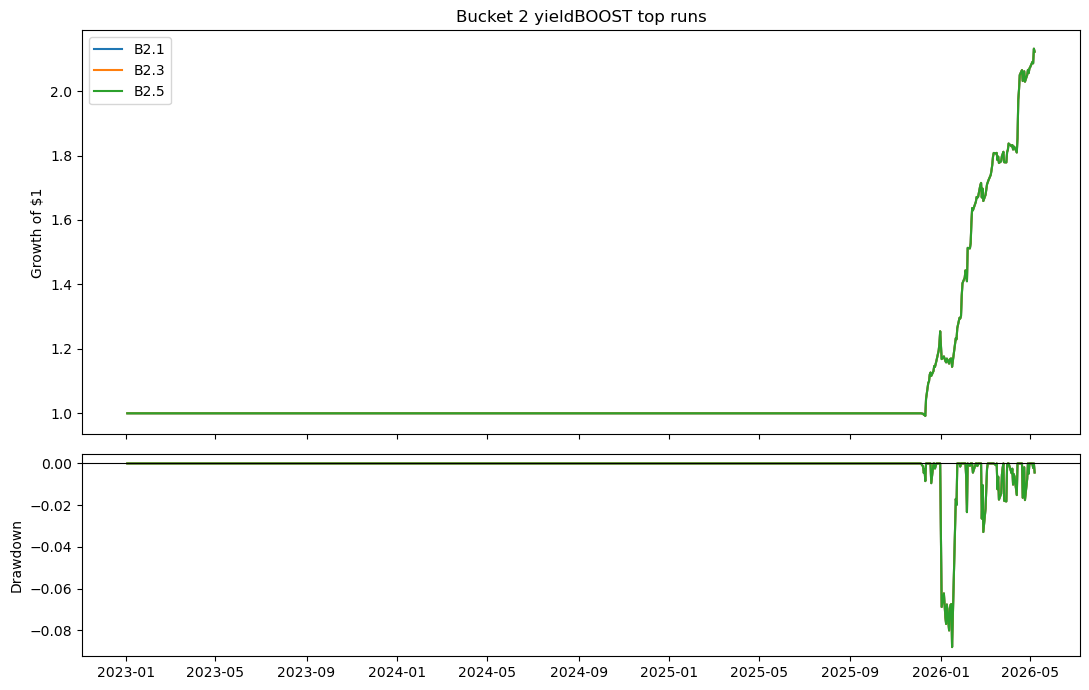

In [ ]:
B2_RESULTS = pd.DataFrame()
B2_CURVES = {}
B2_SIZED = {}
if 2 in EXP["run_buckets"]:
    B2_RESULTS, B2_CURVES, B2_SIZED = run_bucket_grid(2, GRID_B2)
    display(B2_RESULTS[["label", "CAGR", "vol", "Sharpe", "max_dd", "hit_rate", "turnover_x_capital", "n_pairs", "caps_applied", "cov_applied", "borrow_aversion", "eq_blend", "score_concavity_p", "max_name_weight", "max_underlying_weight", "min_net_edge", "missing_shares_cap", "min_listing_age_days"]])
    plot_result({k: B2_CURVES[k] for k in B2_RESULTS["label"].head(3)}, "Bucket 2 yieldBOOST top runs")

### Bucket 2 Sizing Diagnosis

This table explains the top Bucket 2 run by showing the selected gross weights beside net edge, average borrow, beta, shares available, and inception. If a name ranks high despite weaker edge, it is usually because higher-edge names are liquidity-constrained or filtered by the net-edge gate.

In [ ]:
B2_DIAGNOSTIC = pd.DataFrame()
if B2_RESULTS is not None and not B2_RESULTS.empty:
    _b2_best_label = str(B2_RESULTS.iloc[0]["label"])
    _b2_best = B2_SIZED.get(_b2_best_label, pd.DataFrame()).copy()
    if not _b2_best.empty:
        _b2_best["ETF"] = _b2_best["ETF"].astype(str).map(norm_sym)
        _b2_best["Underlying"] = _b2_best["Underlying"].astype(str).map(norm_sym)
        _gross = pd.to_numeric(_b2_best["gross_target_usd"], errors="coerce").fillna(0.0).clip(lower=0.0)
        _b2_best["gross_weight"] = _gross / max(float(_gross.sum()), 1e-12)
        _b2_best["borrow_avg_annual"] = _b2_best["ETF"].map(BORROW_BY_ETF)
        _b2_best["pair"] = _b2_best["ETF"] + "/" + _b2_best["Underlying"]
        _b2_best["inception"] = list(zip(_b2_best["ETF"], _b2_best["Underlying"]))
        _b2_best["inception"] = _b2_best["inception"].map(INCEPTION)
        _cols = ["pair", "gross_weight", "net_edge_p50_annual", "borrow_avg_annual", "Beta", "shares_available", "borrow_price_ref", "inception"]
        B2_DIAGNOSTIC = _b2_best.sort_values("gross_weight", ascending=False)[[c for c in _cols if c in _b2_best.columns]].reset_index(drop=True)
        _b2_mp = float(
            (
                ((strategy_cfg.get("gross_sizing_caps") or {}).get("per_sleeve") or {})
                .get("whitelist_stock", {}) or {}
            ).get("max_pair_weight", 0.20)
        )
        _mx = float(B2_DIAGNOSTIC["gross_weight"].max()) if not B2_DIAGNOSTIC.empty else float("nan")
        print(
            f"B2 within-run max gross_weight={_mx:.4f} (YAML per_sleeve whitelist_stock max_pair_weight={_b2_mp:.4f}). "
            "Re-run the section 4 helpers cell after changing generate_trade_plan.py."
        )
        display(B2_DIAGNOSTIC.head(20))
        if "BBYY" in set(_b2_best["ETF"]):
            print("BBYY is still selected; inspect its net edge / borrow / shares row below:")
            display(B2_DIAGNOSTIC[B2_DIAGNOSTIC["pair"].str.startswith("BBYY/")])
    else:
        print("No sized pairs found for the best Bucket 2 run.")

B2 within-run max gross_weight=0.2000 (YAML per_sleeve whitelist_stock max_pair_weight=0.2000). Re-run the section 4 helpers cell after changing generate_trade_plan.py.


,pair,gross_weight,net_edge_p50_annual,borrow_avg_annual,Beta,shares_available,borrow_price_ref,inception
0,COYY/COIN,0.2000,0.4574,0.2925,0.4142,75000,3.8750,2025-07-29
1,IOYY/IONQ,0.1375,0.7084,0.1021,0.3146,5000,9.2750,2025-11-04
2,MTYY/MSTR,0.1262,0.6266,0.1082,0.3666,0,4.7600,2025-09-23
3,SMYY/SMCI,0.1262,0.6177,0.1486,0.3070,0,8.9850,2025-09-30
4,FBYY/META,0.0953,0.4890,0.0682,0.5324,1000,13.0750,2025-10-22
5,XBTY/IBIT,0.0857,0.5669,0.0455,0.5245,1000,7.0080,2025-05-13
6,MAAY/MARA,0.0776,0.6613,0.0920,0.3013,300,7.3800,2025-11-04
7,QBY/QBTS,0.0759,0.6474,0.1629,0.2777,100,9.6100,2025-12-01
8,HMYY/HIMS,0.0756,0.6813,0.2180,0.2713,100,7.4350,2025-12-02


## 8. Bucket 3 Independent Backtest

Bucket 3 is isolated to the flow-program mechanics: configured short universe, configured/fitted weekly deployment, borrow cap, edge threshold, and max ticker concentration. It does not pull in Bucket 1/2/4 sizing machinery.

,label,CAGR,vol,Sharpe,max_dd,hit_rate,turnover_x_capital,avg_gross,weekly_notional,borrow_cap,edge_threshold,max_ticker_concentration,max_name_weight,max_underlying_weight
0,B3.1,0.1104,0.1074,1.0281,-0.1614,0.5352,0.3974,"118,482.9523","1,300.0000",0.4000,0.0000,0.2500,0.4000,0.5000
1,B3.2,0.1104,0.1074,1.0281,-0.1614,0.5352,0.3974,"118,482.9523","1,300.0000",0.5500,0.0000,0.2500,0.4000,0.5000
2,B3.3,0.1636,0.1619,1.0106,-0.2404,0.5352,0.6380,"185,516.5830","2,000.0000",0.4000,0.0000,0.2500,0.4000,0.5000
3,B3.4,0.1636,0.1619,1.0106,-0.2404,0.5352,0.6380,"185,516.5830","2,000.0000",0.5500,0.0000,0.2500,0.4000,0.5000


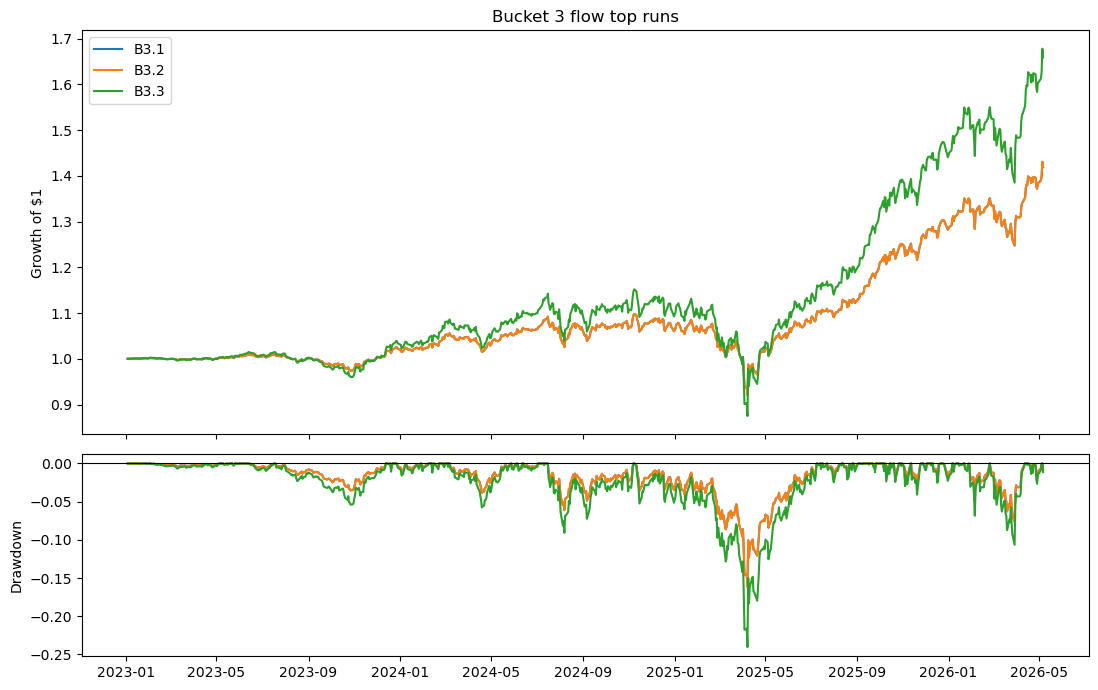

In [ ]:
B3_RESULTS = pd.DataFrame()
B3_CURVES = {}
B3_SIZED = {}
if 3 in EXP["run_buckets"]:
    B3_RESULTS, B3_CURVES, B3_SIZED = run_bucket_grid(3, GRID_B3)
    display(B3_RESULTS[["label", "CAGR", "vol", "Sharpe", "max_dd", "hit_rate", "turnover_x_capital", "avg_gross", "weekly_notional", "borrow_cap", "edge_threshold", "max_ticker_concentration", "max_name_weight", "max_underlying_weight"]])
    plot_result({k: B3_CURVES[k] for k in B3_RESULTS["label"].head(3)}, "Bucket 3 flow top runs")

## 9. Bucket 4 Independent Backtest

Bucket 4 uses the v6 portfolio-style sizing override (`compute_v6_b4_pf_weight_dict`) and then runs through the GTP mirror so caps and covariance are still applied after the v6 internal weights.

**Hedge in the backtest:** `EXP["b4_dynamic_hedge"]` (and grid key `b4_dynamic_hedge`) choose whether leg sizing uses the time-varying **`v6_opt2_h_daily_map`** hedge, or keeps the **static** GTP legs from **`partial_hedge_ratio`** in `strategy_config.yml`. Sizing from the mirror is unchanged; only the simulator’s leg convention toggles.

[B4] always_include patched UVIX: coerced Beta<0 + inverse_shortable (no strict inverse_shortable row)
[B4] always_include patched UVIX: coerced Beta<0 + inverse_shortable (no strict inverse_shortable row)


,label,CAGR,vol,Sharpe,max_dd,hit_rate,turnover_x_capital,n_pairs,caps_applied,cov_applied,v6_b4,borrow_cap,max_name_weight,max_underlying_weight,b4_dynamic_hedge,partial_hedge_ratio,gross_leverage,rebalance_freq
0,B4.1,-0.0084,0.0037,-2.2532,-0.0276,0.0155,1.0281,10,True,True,True,0.9000,0.1800,0.3000,False,1.0000,1.0000,2W-FRI
1,B4.2,-0.0084,0.0037,-2.2532,-0.0276,0.0155,1.0281,10,True,True,True,1.2000,0.1800,0.3000,False,1.0000,1.0000,2W-FRI


,pair,etf,underlying,risk_symbol,expected_decay_annual,decay_eff,borrow_etf_annual,base_score,risk_raw,beta_scale,...,risk_denom,old_score,new_score,old_weight,new_weight_raw,new_weight_signal,cov_contrib_norm,cov_penalty,cov_obs,new_weight
0,QBTZ/QBTS,QBTZ,QBTS,QBTS,2.6246,2.6246,0.5761,0.3763,0.0000,2.0101,...,1.0000,0.3763,0.3763,0.0503,0.0577,0.0572,1.0000,0.5405,0,0.1573
1,ASTN/ASTS,ASTN,ASTS,ASTS,2.4566,2.4566,0.4889,0.4632,0.0000,1.9894,...,1.0000,0.4632,0.4632,0.0620,0.0710,0.0704,1.5151,0.4371,0,0.1566
2,IREZ/IREN,IREZ,IREN,IREN,2.5531,2.5531,0.7771,0.2151,0.0000,2.0126,...,1.0000,0.2151,0.2151,0.0288,0.0330,0.0327,0.3267,0.7827,0,0.1302
3,APLZ/APLD,APLZ,APLD,APLD,2.7508,2.7508,0.3581,0.8315,0.0000,2.0124,...,1.0000,0.8315,0.8315,0.1112,0.1274,0.1264,4.8812,0.1942,0,0.1249
4,BEZ/BE,BEZ,BE,BE,2.2634,2.2634,0.8159,0.1744,0.0000,2.0092,...,1.0000,0.1744,0.1744,0.0233,0.0267,0.0265,0.2146,0.8457,0,0.1140
5,UVIX/SVIX,UVIX,SVIX,UVIX,0.9914,0.9914,0.0503,0.9481,0.0000,2.0000,...,1.0000,0.9481,0.9481,0.1268,0.1452,0.1441,8.6155,0.1201,881,0.0881
6,SMZ/SMR,SMZ,SMR,SMR,2.9571,2.9571,0.2536,1.3708,0.0000,2.0013,...,1.0000,1.3708,1.3708,0.1834,0.2100,0.2083,13.2669,0.0815,0,0.0863
7,CLSZ/CLSK,CLSZ,CLSK,CLSK,2.5789,2.5789,0.1146,2.0857,0.0000,2.0203,...,1.0000,2.0857,2.0857,0.2790,0.3195,0.3170,30.7150,0.0369,0,0.0595
8,MSDD/MSTR,MSDD,MSTR,MSTR,0.9868,0.9868,0.1215,0.7796,0.4928,1.9948,...,3.9771,0.7796,0.0490,0.1043,0.0075,0.0074,0.0556,0.9549,81,0.0362
9,CONI/COIN,CONI,COIN,COIN,0.6767,0.6767,0.5604,0.1017,0.5678,1.9187,...,4.4731,0.1017,0.0057,0.0136,0.0009,0.0050,0.0603,0.9512,272,0.0242


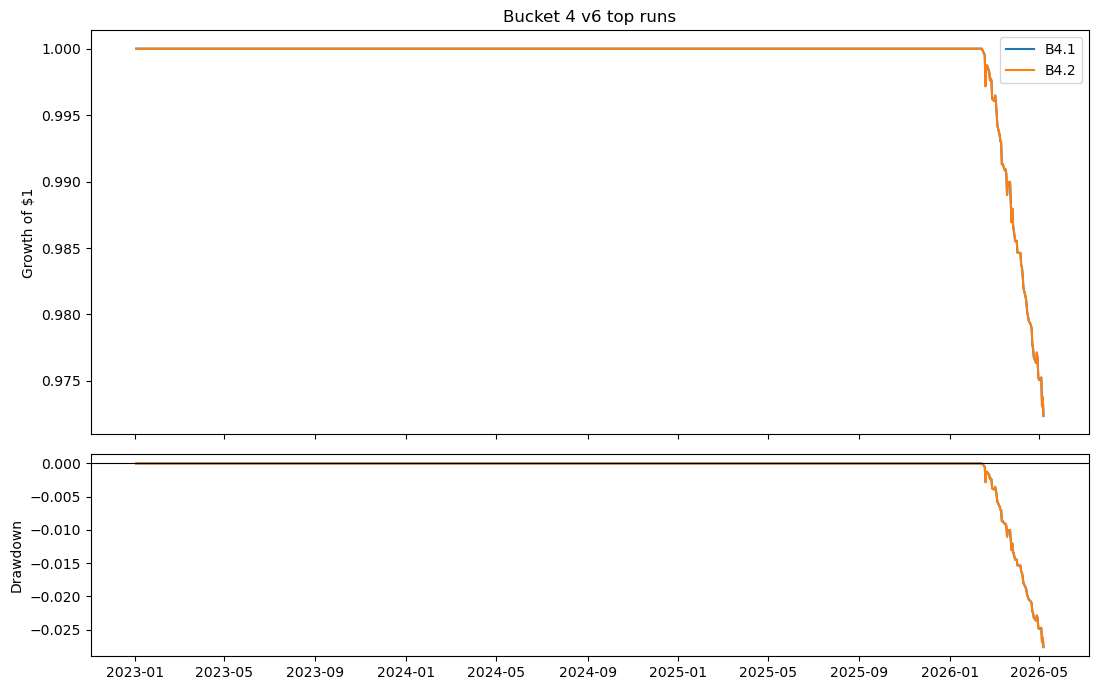

In [ ]:
B4_RESULTS = pd.DataFrame()
B4_CURVES = {}
B4_SIZED = {}
if 4 in EXP["run_buckets"]:
    if not V6_GLOBALS_READY:
        V6_GLOBALS_READY = load_or_build_v6_globals()
    if not V6_GLOBALS_READY:
        raise RuntimeError(
            "Bucket 4 requested but v6 globals could not be loaded or built. "
            "Allow auto-bootstrap (EXP['v6_b4_allow_auto_bootstrap']=True), run the v6 cell after data load, "
            "or place a valid notebooks/v6_b4_gtp_cache.pkl."
        )
    B4_RESULTS, B4_CURVES, B4_SIZED = run_bucket_grid(4, GRID_B4)
    display(B4_RESULTS[["label", "CAGR", "vol", "Sharpe", "max_dd", "hit_rate", "turnover_x_capital", "n_pairs", "caps_applied", "cov_applied", "v6_b4", "borrow_cap", "max_name_weight", "max_underlying_weight", "b4_dynamic_hedge", "partial_hedge_ratio", "gross_leverage", "rebalance_freq"]])
    display(V6_B4_DIAG.head(20))
    plot_result({k: B4_CURVES[k] for k in B4_RESULTS["label"].head(3)}, "Bucket 4 v6 top runs")

## 10. Combined Portfolio Backtest

The combined book uses the configured sleeve percentages from `strategy_config.yml`. Bucket 1 and Bucket 2 are sized through the GTP mirror; Bucket 4 receives the v6 override; Bucket 3 is reported standalone because it is an accumulating flow sleeve rather than a rebalance-to-target stock sleeve. Book-level covariance is applied to the stock sleeves when enabled.

,label,CAGR,vol,Sharpe,max_dd,hit_rate,turnover_x_capital,avg_gross,avg_positions
0,Combined + Bucket 3 flow,0.2880,0.1008,2.8575,-0.0799,0.5840,49.3766,"3,621,871.3616",129.5352
1,Combined stock sleeves,0.2137,0.0833,2.5649,-0.0767,0.5721,48.9793,"3,503,388.4093",117.5352
2,Bucket 3 flow,0.1104,0.1074,1.0281,-0.1614,0.5352,0.3974,"118,482.9523",12.0000


Combined sizing diag: {'core_budget': 1125000.0, 'wl_budget': 1250000.0, 'b4_budget': 125000.0, 'n_core': 222, 'n_wl': 18, 'n_b4': 24}
Book-level covariance applied: True


,peak,trough,recovery,drawdown
0,2025-02-20,2025-04-08,2025-05-19,-0.0799
1,2026-02-24,2026-03-30,2026-04-17,-0.0713
2,2025-02-20,2025-04-04,2025-05-19,-0.0689
3,2025-02-20,2025-04-07,2025-05-19,-0.0679
4,2026-02-24,2026-03-27,2026-04-17,-0.0672


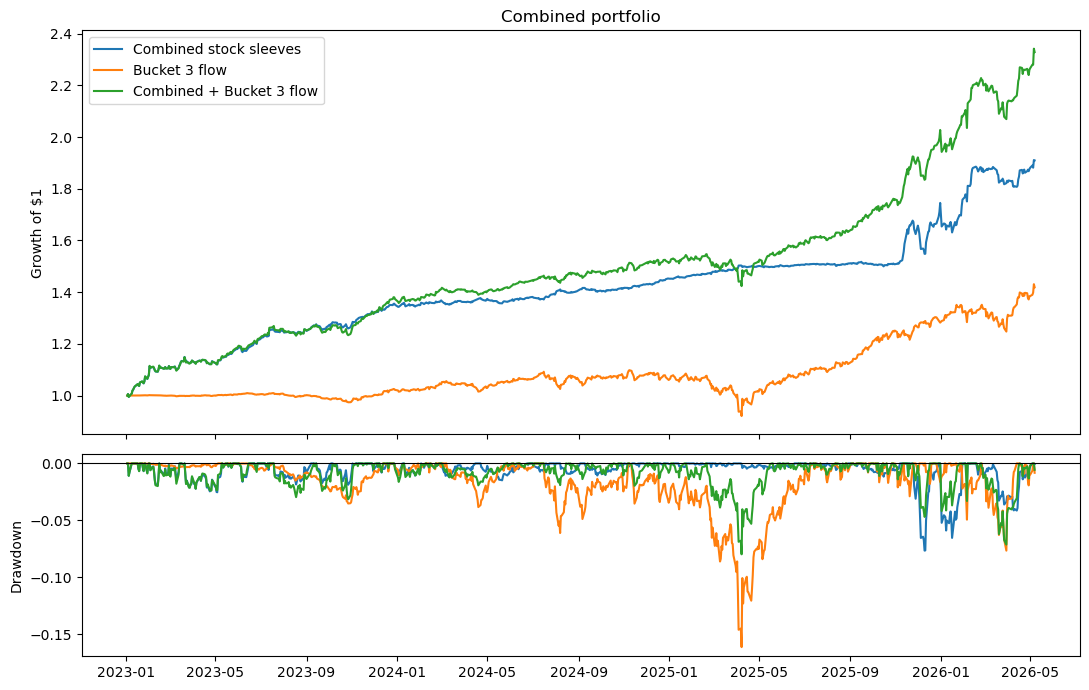

In [ ]:
COMBINED_RESULT = pd.DataFrame()
COMBINED_CURVES = {}
COMBINED_SIZED = pd.DataFrame()
COMBINED_DIAG = {}


def best_params(results: pd.DataFrame, grid: list[dict]) -> dict:
    if results is None or results.empty:
        return grid[0] if grid else {}
    best_label = str(results.iloc[0]["label"])
    idx = int(best_label.split(".")[-1]) - 1
    return grid[max(0, min(idx, len(grid) - 1))]


if EXP["run_combined"]:
    combined_params = {
        "yieldboost_only": True,
        "enable_b4": True,
    }
    if combined_params.get("enable_b4", True) and not V6_GLOBALS_READY:
        V6_GLOBALS_READY = load_or_build_v6_globals()
    # Keep defaults conservative; the independent grids above identify candidate overrides.
    COMBINED_SIZED, COMBINED_DIAG, COMBINED_V6_META = size_bucket(
        "combined",
        combined_params,
        combined=True,
        book_covariance=bool(EXP["book_level_covariance"]),
    )
    stock_bt, stock_meta, _ = simulate_sized_pairs(
        COMBINED_SIZED,
        label="Combined stock sleeves",
        gross_leverage=EXP["gross_leverage"],
        min_active_pairs_by_sleeve=SLEEVE_START_MIN_ACTIVE_PAIRS or None,
        b4_dynamic_hedge=bool(EXP.get("b4_dynamic_hedge", True)),
    )
    COMBINED_CURVES["Combined stock sleeves"] = stock_bt

    if 3 in EXP["run_buckets"]:
        b3_params = best_params(B3_RESULTS, GRID_B3)
        b3_bt, b3_meta, _ = simulate_bucket3(b3_params)
        COMBINED_CURVES["Bucket 3 flow"] = b3_bt
        # Approximate combined NAV by adding incremental PnL streams on shared seed NAV(0).
        combo = stock_bt.copy()
        aligned_b3 = b3_bt.reindex(combo.index).ffill()
        nav0 = float(EXP.get("initial_capital_usd", EXP["capital_usd"]))
        combo["nav"] = nav0 + (stock_bt["nav"] - nav0) + (aligned_b3["nav"] - nav0)
        combo["daily_return"] = combo["nav"].pct_change().fillna(0.0)
        combo["gross"] = stock_bt["gross"].fillna(0.0) + aligned_b3["gross"].fillna(0.0)
        combo["net"] = stock_bt["net"].fillna(0.0) + aligned_b3["net"].fillna(0.0)
        combo["turnover"] = stock_bt["turnover"].fillna(0.0) + aligned_b3["turnover"].fillna(0.0)
        combo["n_positions"] = stock_bt["n_positions"].fillna(0.0) + aligned_b3["n_positions"].fillna(0.0)
        combo["effective_gross_leverage"] = combo["gross"].astype(float) / combo["nav"].astype(float).replace(0, np.nan)
        combo["borrow_drag"] = stock_bt["borrow_drag"].fillna(0.0) + aligned_b3["borrow_drag"].fillna(0.0)
        combo["fee_slippage_drag"] = stock_bt["fee_slippage_drag"].fillna(0.0) + aligned_b3["fee_slippage_drag"].fillna(0.0)
        COMBINED_CURVES["Combined + Bucket 3 flow"] = combo
    else:
        combo = stock_bt

    rows = [performance_stats(v, label=k) for k, v in COMBINED_CURVES.items()]
    COMBINED_RESULT = pd.DataFrame(rows).sort_values("Sharpe", ascending=False).reset_index(drop=True)
    display(COMBINED_RESULT[["label", "CAGR", "vol", "Sharpe", "max_dd", "hit_rate", "turnover_x_capital", "avg_gross", "avg_positions"]])
    print("Combined sizing diag:", {k: COMBINED_DIAG.get(k) for k in ("core_budget", "wl_budget", "b4_budget", "n_core", "n_wl", "n_b4")})
    print("Book-level covariance applied:", bool((COMBINED_DIAG.get("covariance_balance") or {}).get("applied")))
    plot_result(COMBINED_CURVES, "Combined portfolio")
    display(largest_drawdowns(combo, n=5))

## 11. Results / Comparison

Compact decision tables only. Raw diagnostics stay behind `EXP["debug"]`.


Bucket 1


,start,end,final_nav,CAGR,vol,Sharpe,max_dd,hit_rate,avg_gross,avg_positions,...,estimated_tcost_usd,tcost_half_spread_bps,label,min_net_edge,borrow_aversion,eq_blend,score_concavity_p,cov_penalty,max_name_weight,max_underlying_weight
0,2023-01-03,2026-05-07,"992,260.9753",0.1484,0.0506,2.9344,-0.0227,0.5757,"3,481,267.3265",112.8367,...,"12,688.4183",5.0000,B1.4,0.0000,0.3500,0.1000,0.8500,0.8500,0.1000,0.1800
1,2023-01-03,2026-05-07,"983,674.8816",0.1454,0.0501,2.9041,-0.0220,0.5745,"3,467,705.3531",112.8367,...,"12,615.3493",5.0000,B1.2,0.0000,0.2000,0.1000,0.8500,0.8500,0.1000,0.1800
2,2023-01-03,2026-05-07,"978,077.6186",0.1435,0.0500,2.8719,-0.0256,0.5733,"3,451,494.6889",109.2491,...,"12,654.9856",5.0000,B1.6,0.0600,0.2000,0.1000,0.8500,0.8500,0.1000,0.1800
3,2023-01-03,2026-05-07,"995,677.2626",0.1496,0.0522,2.8682,-0.0259,0.5673,"3,489,290.4670",112.8367,...,"13,075.7703",5.0000,B1.3,0.0000,0.3500,0.1000,1.0000,0.8500,0.1000,0.1800
4,2023-01-03,2026-05-07,"988,261.6048",0.1470,0.0518,2.8372,-0.0253,0.5697,"3,478,996.0774",112.8367,...,"13,025.8607",5.0000,B1.1,0.0000,0.2000,0.1000,1.0000,0.8500,0.1000,0.1800
5,2023-01-03,2026-05-07,"983,377.0306",0.1453,0.0519,2.8003,-0.0290,0.5709,"3,464,909.7119",109.2491,...,"13,068.8028",5.0000,B1.5,0.0600,0.2000,0.1000,1.0000,0.8500,0.1000,0.1800



Bucket 2 yieldBOOST


,start,end,final_nav,CAGR,vol,Sharpe,max_dd,hit_rate,avg_gross,avg_positions,...,tcost_half_spread_bps,label,borrow_aversion,eq_blend,score_concavity_p,max_name_weight,max_underlying_weight,min_net_edge,missing_shares_cap,min_listing_age_days
0,2023-01-03,2026-05-07,"1,326,448.1002",0.2527,0.1130,2.2358,-0.0880,0.0834,"484,129.8028",2.2527,...,5.0000,B2.1,0.0000,0.0000,1.0000,0.2000,0.4000,0.3500,0.0200,0
1,2023-01-03,2026-05-07,"1,326,448.1002",0.2527,0.1130,2.2358,-0.0880,0.0834,"484,129.8028",2.2527,...,5.0000,B2.3,0.0000,0.0000,1.2500,0.2000,0.4000,0.3500,0.0200,0
2,2023-01-03,2026-05-07,"1,326,448.1002",0.2527,0.1130,2.2358,-0.0880,0.0834,"484,129.8028",2.2527,...,5.0000,B2.5,0.0000,0.0200,1.0000,0.2000,0.4000,0.3500,0.0200,0
3,2023-01-03,2026-05-07,"625,000.0000",0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,...,5.0000,B2.2,0.0000,0.0000,1.0000,0.2000,0.4000,0.5000,0.0200,0
4,2023-01-03,2026-05-07,"625,000.0000",0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,...,5.0000,B2.4,0.0000,0.0000,1.2500,0.2000,0.4000,0.5000,0.0200,0
5,2023-01-03,2026-05-07,"625,000.0000",0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,...,5.0000,B2.6,0.0000,0.0200,1.0000,0.2000,0.4000,0.5000,0.0200,0



Bucket 3 flow


...


Bucket 4 inverse v6


,start,end,final_nav,CAGR,vol,Sharpe,max_dd,hit_rate,avg_gross,avg_positions,...,estimated_tcost_usd,tcost_half_spread_bps,label,borrow_cap,min_net_edge,max_name_weight,max_underlying_weight,partial_hedge_ratio,gross_leverage,v6_pf_params
0,2023-01-03,2026-05-07,"607,725.1087",-0.0084,0.0037,-2.2532,-0.0276,0.0155,"42,714.5543",1.2920,...,321.2952,5.0000,B4.1,0.9000,0.0000,0.1800,0.3000,1.0000,1.0000,None
1,2023-01-03,2026-05-07,"607,725.1087",-0.0084,0.0037,-2.2532,-0.0276,0.0155,"42,714.5543",1.2920,...,321.2952,5.0000,B4.2,1.2000,0.0000,0.1800,0.3000,1.0000,1.0000,None



Combined


,start,end,final_nav,CAGR,vol,Sharpe,max_dd,hit_rate,avg_gross,avg_positions,turnover_x_capital,turnover_dollar,borrow_paid_usd,estimated_tcost_usd,tcost_half_spread_bps,avg_effective_gross_leverage,label
0,2023-01-03,2026-05-07,"1,455,373.3803",0.2880,0.1008,2.8575,-0.0799,0.5840,"3,621,871.3616",129.5352,49.3766,"30,860,386.8382","483,876.1197","15,430.1934",5.0000,3.9048,Combined + Bucket 3 flow
1,2023-01-03,2026-05-07,"1,193,531.0084",0.2137,0.0833,2.5649,-0.0767,0.5721,"3,503,388.4093",117.5352,48.9793,"30,612,041.1131","483,876.1197","15,306.0206",5.0000,3.9730,Combined stock sleeves
2,2023-01-03,2026-05-07,"886,842.3719",0.1104,0.1074,1.0281,-0.1614,0.5352,"118,482.9523",12.0000,0.3974,"248,345.7251","48,423.9046",124.1729,5.0000,0.1684,Bucket 3 flow


,section,label,CAGR,vol,Sharpe,max_dd,hit_rate,turnover_x_capital,turnover_dollar,borrow_paid_usd,...,min_active_pair_gate,missing_shares_cap,min_listing_age_days,weekly_notional,borrow_cap,edge_threshold,max_ticker_concentration,partial_hedge_ratio,gross_leverage,v6_pf_params
0,Bucket 1,B1.4,0.1484,0.0506,2.9344,-0.0227,0.5757,40.6029,"25,376,836.6010","326,779.2567",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bucket 2 yieldBOOST,B2.1,0.2527,0.1130,2.2358,-0.0880,0.0834,9.3097,"5,818,571.1722","177,075.8824",...,whitelist_stock>=8,0.0200,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bucket 3 flow,B3.1,0.1104,0.1074,1.0281,-0.1614,0.5352,0.3974,"248,345.7251","48,423.9046",...,NaN,NaN,NaN,"1,300.0000",0.4000,0.0000,0.2500,NaN,NaN,NaN
3,Bucket 4 inverse v6,B4.1,-0.0084,0.0037,-2.2532,-0.0276,0.0155,1.0281,"642,590.4116","23,385.5291",...,inverse_decay_bucket4>=8,NaN,NaN,NaN,0.9000,NaN,NaN,1.0000,1.0000,NaN
4,Combined,Combined + Bucket 3 flow,0.2880,0.1008,2.8575,-0.0799,0.5840,49.3766,"30,860,386.8382","483,876.1197",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


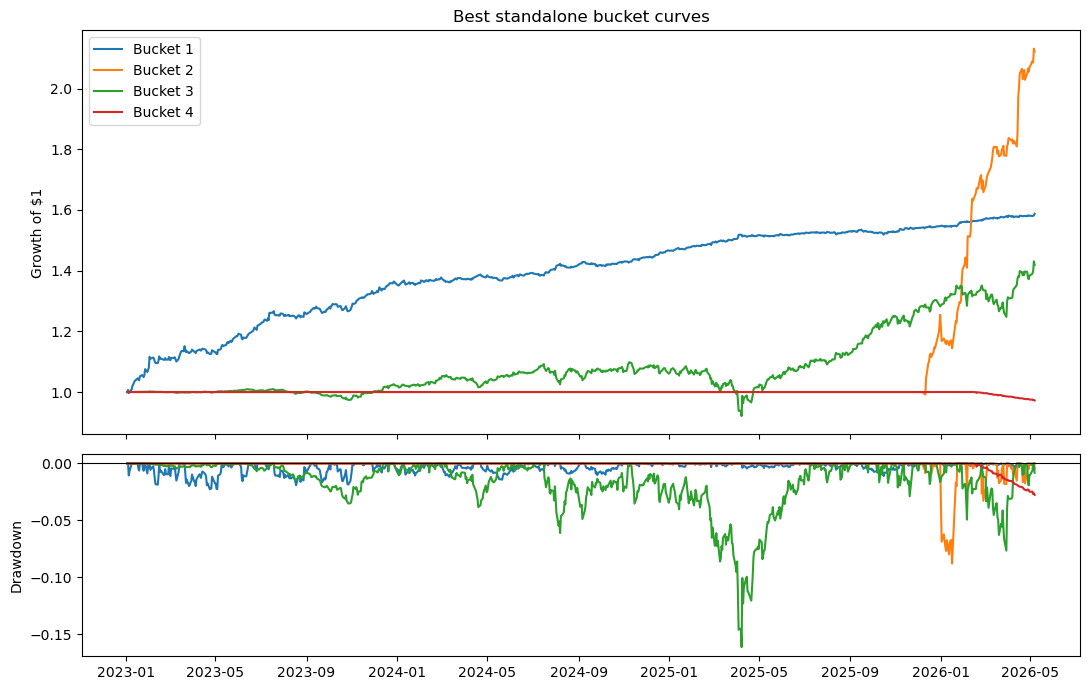

In [ ]:
SUMMARY_TABLES = {
    "Bucket 1": B1_RESULTS,
    "Bucket 2 yieldBOOST": B2_RESULTS,
    "Bucket 3 flow": B3_RESULTS,
    "Bucket 4 inverse v6": B4_RESULTS,
    "Combined": COMBINED_RESULT,
}

for name, df in SUMMARY_TABLES.items():
    if df is not None and not df.empty:
        print(f"\n{name}")
        display(df)

all_top = []
for name, df in SUMMARY_TABLES.items():
    if df is not None and not df.empty:
        row = df.iloc[0].to_dict()
        row["section"] = name
        all_top.append(row)
TOPLINE = pd.DataFrame(all_top)
if not TOPLINE.empty:
    _pref = ["section", "label", "CAGR", "vol", "Sharpe", "max_dd", "hit_rate", "turnover_x_capital", "turnover_dollar", "borrow_paid_usd", "fee_slippage_paid_usd", "estimated_tcost_usd", "tcost_half_spread_bps", "avg_gross"]
    _cols = [c for c in _pref if c in TOPLINE.columns] + [c for c in TOPLINE.columns if c not in _pref]
    display(TOPLINE[_cols])

bucket_curves = {}
for results, curves, name in [
    (B1_RESULTS, B1_CURVES, "Bucket 1"),
    (B2_RESULTS, B2_CURVES, "Bucket 2"),
    (B3_RESULTS, B3_CURVES, "Bucket 3"),
    (B4_RESULTS, B4_CURVES, "Bucket 4"),
]:
    if results is not None and not results.empty:
        bucket_curves[name] = curves[str(results.iloc[0]["label"])]
if bucket_curves:
    plot_result(bucket_curves, "Best standalone bucket curves")

if EXP["debug"]:
    display({"combined_diag": COMBINED_DIAG, "v6_meta": V6_B4_META})

## 12. Top Position Investigation

Use this section after the bucket grid cells have run. It visualizes the top positions for the top 3 parameter runs in each bucket so concentration, repeated names, borrow-heavy positions, and underlying crowding are easy to inspect before expanding the grids.


Bucket 1: top positions for top 3 runs


,bucket,run,pair,sleeve,gross_weight,gross_target_usd,Beta,borrow_annual,net_edge_p50_annual,net_decay_annual,inception
0,Bucket 1,B1.4,CRMU/CRML,core_leveraged,0.0113,"28,209.7949",1.9854,0.1529,1.1186,1.5949,2026-02-10
1,Bucket 1,B1.4,NVTX/NVTS,core_leveraged,0.0111,"27,862.7693",1.9842,0.3106,1.1574,1.5089,2025-09-09
2,Bucket 1,B1.4,FLYT/FLY,core_leveraged,0.0106,"26,403.7640",1.9908,0.2285,1.0637,1.2301,2025-10-23
3,Bucket 1,B1.4,KEEX/KEEL,core_leveraged,0.0103,"25,874.0275",1.9992,0.1015,0.9975,1.3331,2025-12-30
4,Bucket 1,B1.4,IREG/IREN,core_leveraged,0.0103,"25,646.7489",1.9899,0.1444,0.9995,0.9514,2025-12-16
5,Bucket 1,B1.4,QBTX/QBTS,core_leveraged,0.0102,"25,561.6626",1.9820,0.1351,0.9902,1.1871,2025-04-25
6,Bucket 1,B1.4,BEX/BE,core_leveraged,0.0101,"25,179.7405",1.9887,0.1592,0.9832,1.2035,2025-11-13
7,Bucket 1,B1.4,ASTX/ASTS,core_leveraged,0.0098,"24,525.3634",1.9961,0.1212,0.9423,1.0988,2025-07-11
8,Bucket 1,B1.4,HUTG/HUT,core_leveraged,0.0097,"24,132.3146",1.9905,0.1440,0.9312,1.2612,2026-01-13
9,Bucket 1,B1.4,IRE/IREN,core_leveraged,0.0094,"23,504.2782",1.9924,0.2331,0.9347,1.2625,2025-10-21



Bucket 2 yieldBOOST: top positions for top 3 runs


,bucket,run,pair,sleeve,gross_weight,gross_target_usd,Beta,borrow_annual,net_edge_p50_annual,net_decay_annual,inception
0,Bucket 2 yieldBOOST,B2.1,COYY/COIN,whitelist_stock,0.2000,"29,547.7244",0.4142,0.2925,0.4574,0.4559,2025-07-29
1,Bucket 2 yieldBOOST,B2.1,IOYY/IONQ,whitelist_stock,0.1375,"20,316.4536",0.3146,0.1021,0.7084,0.4655,2025-11-04
2,Bucket 2 yieldBOOST,B2.1,MTYY/MSTR,whitelist_stock,0.1262,"18,645.4102",0.3666,0.1082,0.6266,1.2101,2025-09-23
3,Bucket 2 yieldBOOST,B2.1,SMYY/SMCI,whitelist_stock,0.1262,"18,645.4102",0.3070,0.1486,0.6177,0.3081,2025-09-30
4,Bucket 2 yieldBOOST,B2.1,FBYY/META,whitelist_stock,0.0953,"14,079.4970",0.5324,0.0682,0.4890,0.5047,2025-10-22
5,Bucket 2 yieldBOOST,B2.1,XBTY/IBIT,whitelist_stock,0.0857,"12,654.4570",0.5245,0.0455,0.5669,0.1780,2025-05-13
6,Bucket 2 yieldBOOST,B2.1,MAAY/MARA,whitelist_stock,0.0776,"11,465.5267",0.3013,0.0920,0.6613,0.8477,2025-11-04
7,Bucket 2 yieldBOOST,B2.1,QBY/QBTS,whitelist_stock,0.0759,"11,213.6101",0.2777,0.1629,0.6474,0.6881,2025-12-01
8,Bucket 2 yieldBOOST,B2.1,HMYY/HIMS,whitelist_stock,0.0756,"11,170.5326",0.2713,0.2180,0.6813,1.4751,2025-12-02
9,Bucket 2 yieldBOOST,B2.3,COYY/COIN,whitelist_stock,0.2000,"29,547.7244",0.4142,0.2925,0.4574,0.4559,2025-07-29



Bucket 3 flow: top positions for top 3 runs


...

,bucket,run,pair,sleeve,gross_weight,gross_target_usd,Beta,borrow_annual,net_edge_p50_annual,net_decay_annual,inception
0,Bucket 4 inverse v6,B4.1,UVIX/SVIX,inverse_decay_bucket4,0.1761,"440,289.3293",-1.9824,0.0503,0.9914,1.9632,2022-03-30
1,Bucket 4 inverse v6,B4.1,QBTZ/QBTS,inverse_decay_bucket4,0.1761,"440,289.3293",-2.0101,0.5441,2.6246,3.5589,2025-10-07
2,Bucket 4 inverse v6,B4.1,BEZ/BE,inverse_decay_bucket4,0.1691,"422,677.7729",-2.0092,0.8811,2.2634,2.1065,2026-02-11
3,Bucket 4 inverse v6,B4.1,ASTN/ASTS,inverse_decay_bucket4,0.1585,"396,260.4150",-1.9894,0.4825,2.4566,2.5422,2026-02-06
4,Bucket 4 inverse v6,B4.1,CONI/COIN,inverse_decay_bucket4,0.1253,"313,313.8862",-1.9187,0.5567,0.6767,0.6079,2024-09-04
5,Bucket 4 inverse v6,B4.1,MSTZ/MSTR,inverse_decay_bucket4,0.1193,"298,155.2700",-2.0050,0.4440,0.7441,1.9323,2024-09-18
6,Bucket 4 inverse v6,B4.1,IREZ/IREN,inverse_decay_bucket4,0.0574,"143,599.9966",-2.0126,0.7789,2.5531,2.8974,2026-01-22
7,Bucket 4 inverse v6,B4.1,MSDD/MSTR,inverse_decay_bucket4,0.0103,"25,767.0002",-1.9948,0.1193,0.9868,1.1621,2025-06-10
8,Bucket 4 inverse v6,B4.1,SMZ/SMR,inverse_decay_bucket4,0.0076,"19,020.0005",-2.0013,0.1619,2.9571,2.3511,2026-02-11
9,Bucket 4 inverse v6,B4.1,CLSZ/CLSK,inverse_decay_bucket4,0.0003,627.0000,-2.0203,0.1507,2.5789,1.8675,2026-02-19



Repeated top pairs across top runs


,bucket,pair,runs_seen,avg_gross_weight,max_gross_weight,avg_borrow
29,Bucket 3 flow,LABD/XBI,3,0.2727,0.2727,0.1523
16,Bucket 2 yieldBOOST,COYY/COIN,3,0.2000,0.2000,0.2925
34,Bucket 3 flow,SOXS/SOXX,3,0.1687,0.1687,0.0880
19,Bucket 2 yieldBOOST,IOYY/IONQ,3,0.1375,0.1375,0.1021
21,Bucket 2 yieldBOOST,MTYY/MSTR,3,0.1262,0.1262,0.1082
23,Bucket 2 yieldBOOST,SMYY/SMCI,3,0.1262,0.1262,0.1486
17,Bucket 2 yieldBOOST,FBYY/META,3,0.0953,0.0953,0.0682
30,Bucket 3 flow,NVDQ/NVDA,3,0.0935,0.0935,0.1752
35,Bucket 3 flow,TSLQ/TSLA,3,0.0935,0.0935,0.0454
27,Bucket 3 flow,DUST/GDX,3,0.0858,0.0858,0.1552



Repeated top underlyings across top runs


,bucket,Underlying,runs_seen,avg_gross_weight,max_gross_weight,avg_borrow
30,Bucket 3 flow,XBI,3,0.2727,0.2727,0.1523
13,Bucket 2 yieldBOOST,COIN,3,0.2000,0.2000,0.2925
28,Bucket 3 flow,SOXX,3,0.1687,0.1687,0.0880
16,Bucket 2 yieldBOOST,IONQ,3,0.1375,0.1375,0.1021
19,Bucket 2 yieldBOOST,MSTR,3,0.1262,0.1262,0.1082
21,Bucket 2 yieldBOOST,SMCI,3,0.1262,0.1262,0.1486
18,Bucket 2 yieldBOOST,META,3,0.0953,0.0953,0.0682
24,Bucket 3 flow,GDX,3,0.0858,0.0858,0.1552
15,Bucket 2 yieldBOOST,IBIT,3,0.0857,0.0857,0.0455
25,Bucket 3 flow,NVDA,3,0.0838,0.0935,0.1111


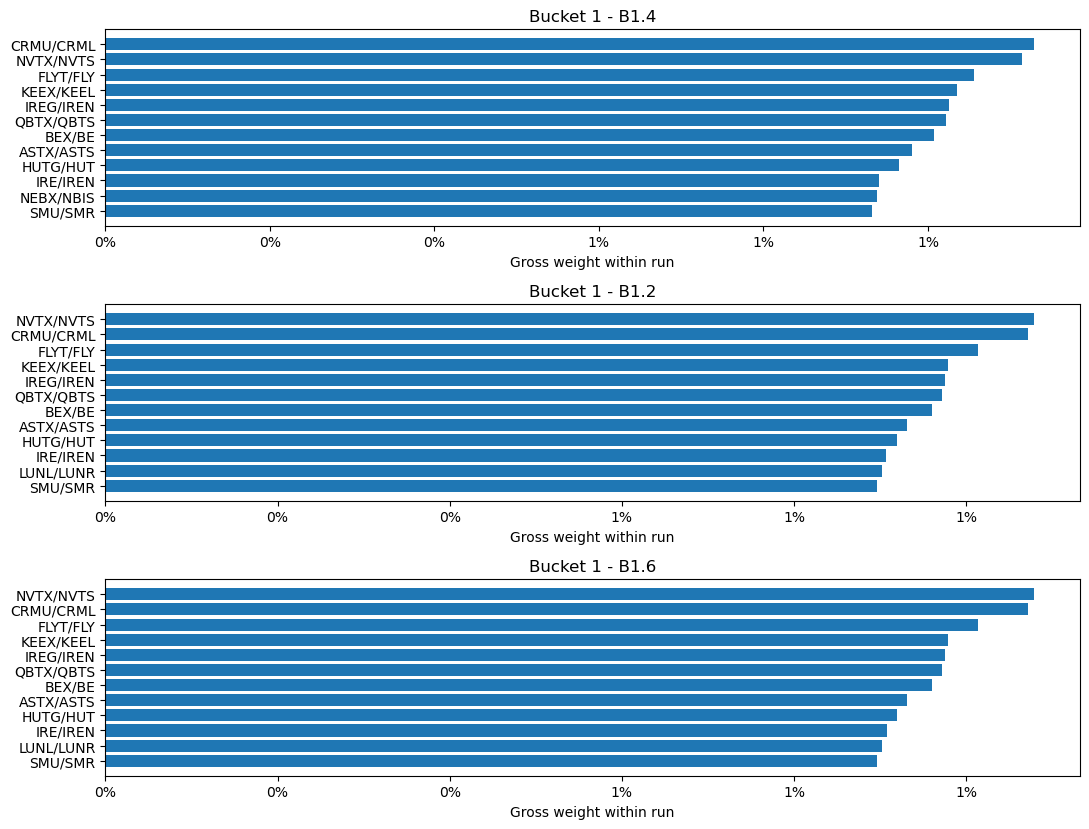

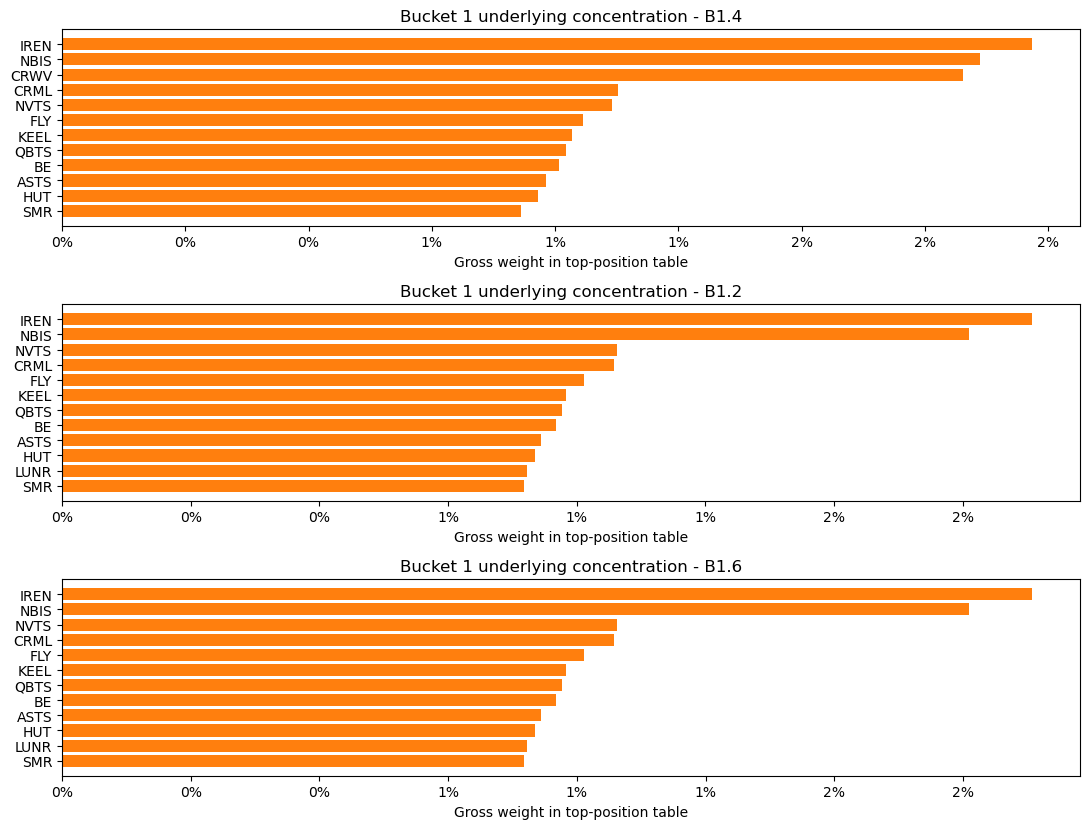

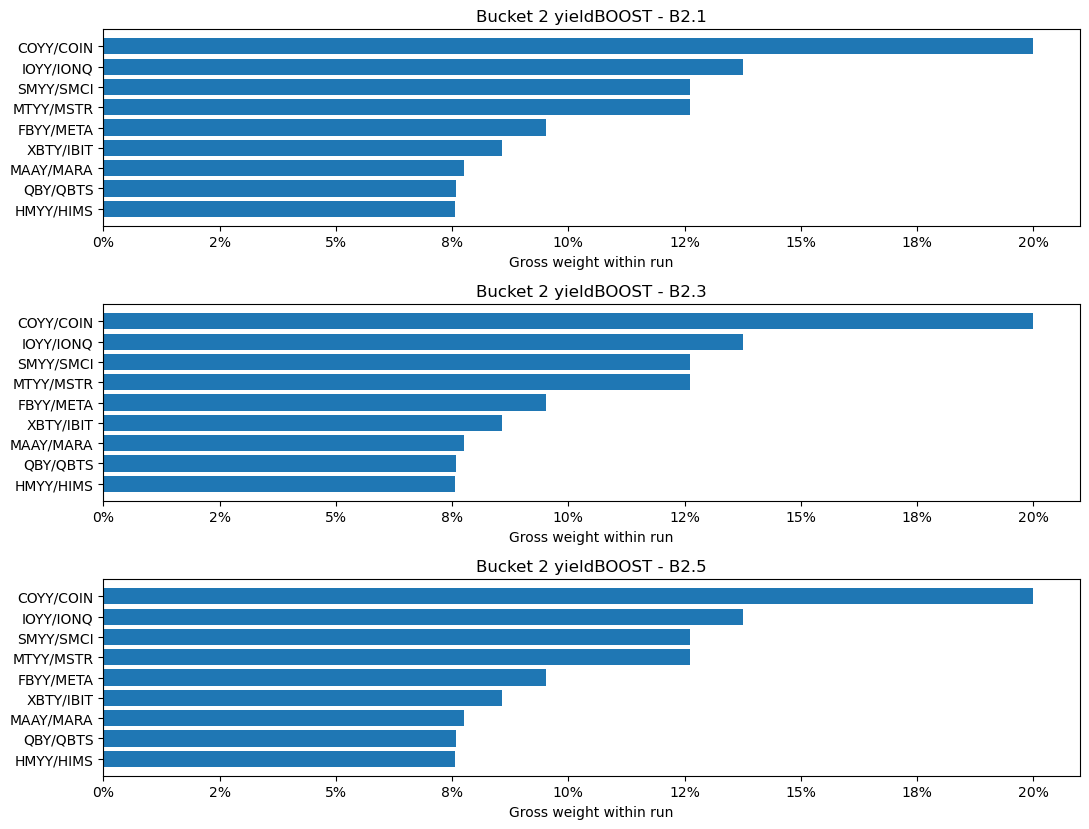

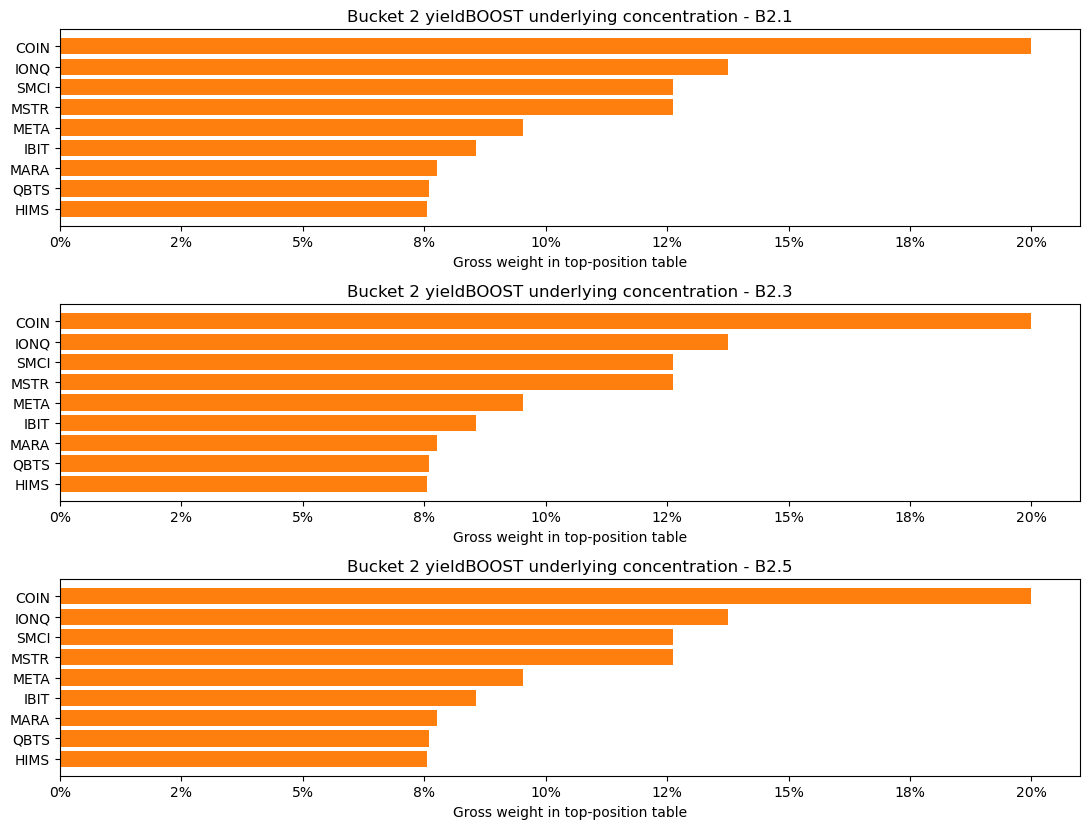

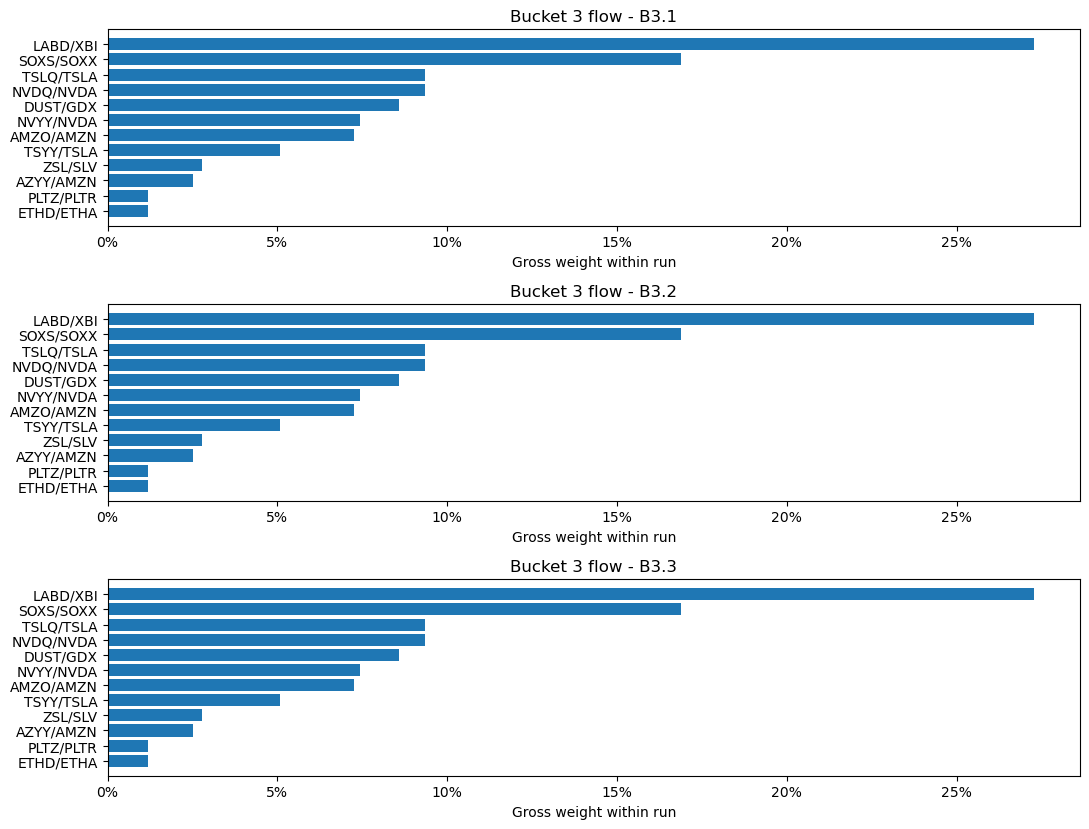

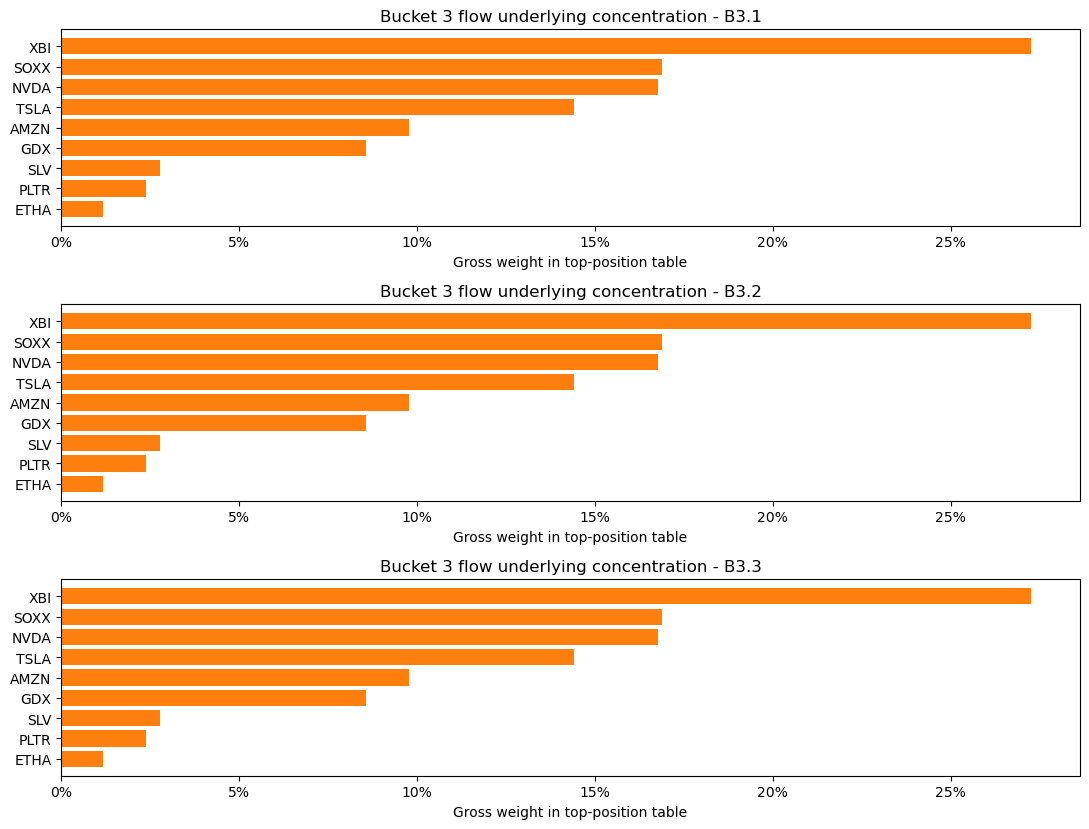

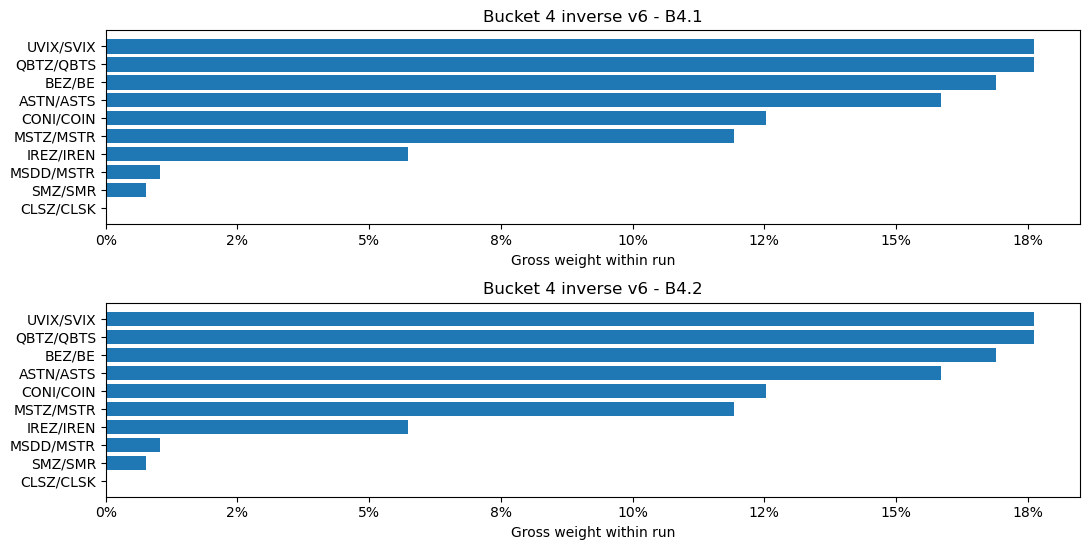

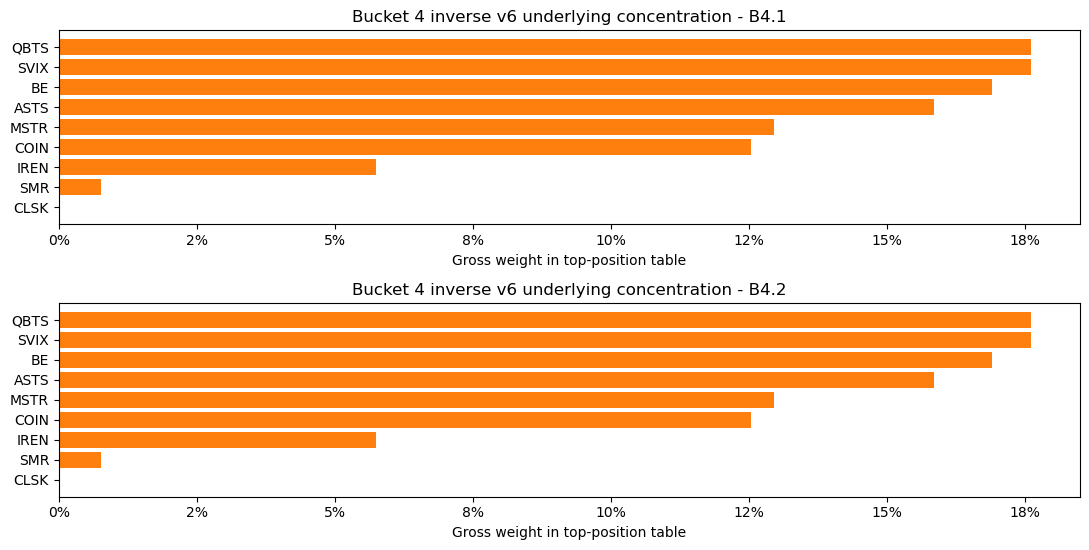

In [ ]:
POSITION_VIEW = {
    "top_runs": 3,
    "top_positions": 15,
    "plot_positions": 12,
}


def _top_run_labels(results: pd.DataFrame, n: int | None = None) -> list[str]:
    if results is None or results.empty or "label" not in results.columns:
        return []
    n = int(n or POSITION_VIEW["top_runs"])
    return [str(x) for x in results["label"].head(n).tolist()]


def _params_for_run_label(label: str, grid: list[dict]) -> dict:
    try:
        idx = int(str(label).split(".")[-1]) - 1
    except Exception:
        idx = 0
    if not grid:
        return {}
    return dict(grid[max(0, min(idx, len(grid) - 1))])


def summarize_sized_positions(
    sized: pd.DataFrame,
    *,
    bucket: str,
    run_label: str,
    top_n: int | None = None,
) -> pd.DataFrame:
    """Return top GTP-sized ETF/underlying pairs by gross target weight."""
    top_n = int(top_n or POSITION_VIEW["top_positions"])
    if sized is None or sized.empty:
        return pd.DataFrame()

    d = sized.copy()
    d["ETF"] = d["ETF"].astype(str).map(norm_sym)
    d["Underlying"] = d["Underlying"].astype(str).map(norm_sym)
    for c in ["gross_target_usd", "long_usd", "short_usd", "Beta", "borrow_current", "net_edge_p50_annual", "net_decay_annual"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")
    gross = d.get("gross_target_usd", pd.Series(0.0, index=d.index)).fillna(0.0).clip(lower=0.0)
    total_gross = float(gross.sum())
    if total_gross <= 0:
        return pd.DataFrame()

    d["gross_weight"] = gross / total_gross
    d["abs_short_weight"] = d.get("short_usd", pd.Series(0.0, index=d.index)).abs() / max(total_gross, 1e-12)
    d["long_weight"] = d.get("long_usd", pd.Series(0.0, index=d.index)) / max(total_gross, 1e-12)
    d["pair"] = d["ETF"] + "/" + d["Underlying"]
    d["bucket"] = bucket
    d["run"] = run_label
    d["borrow_annual"] = d["ETF"].map(BORROW_BY_ETF).fillna(d.get("borrow_current", np.nan))
    d["inception"] = list(zip(d["ETF"], d["Underlying"]))
    d["inception"] = d["inception"].map(INCEPTION)

    cols = [
        "bucket", "run", "pair", "ETF", "Underlying", "sleeve", "gross_weight", "gross_target_usd",
        "long_weight", "abs_short_weight", "Beta", "borrow_annual", "net_edge_p50_annual",
        "net_decay_annual", "inception",
    ]
    keep = [c for c in cols if c in d.columns]
    return d.sort_values("gross_weight", ascending=False).head(top_n)[keep].reset_index(drop=True)


def reconstruct_bucket3_positions(params: dict, *, run_label: str, top_n: int | None = None) -> pd.DataFrame:
    """Bucket 3 is an accumulating flow sleeve, so reconstruct top flow shorts from config weights and gates."""
    top_n = int(top_n or POSITION_VIEW["top_positions"])
    flow = sleeves_cfg.get("flow_program") or {}
    weights = (flow.get("weighting") or {}).get("weights") or {}
    tickers = [norm_sym(t) for t in ((flow.get("universe") or {}).get("shorts") or [])]
    tickers = [t for t in tickers if t in PRICES]
    if not tickers:
        return pd.DataFrame()

    raw_w = pd.Series({t: float(weights.get(t, 1.0)) for t in tickers}, dtype=float).clip(lower=0.0)
    raw_w = raw_w / float(raw_w.sum()) if float(raw_w.sum()) > 0 else pd.Series(1.0 / len(tickers), index=tickers)

    weekly_notional = float(params.get("weekly_notional", flow.get("fixed_usd_per_week", 1300.0) or 1300.0))
    borrow_cap = float(params.get("borrow_cap", (flow.get("rules") or {}).get("hard_borrow_cap", 0.40) or 0.40))
    edge_threshold = float(params.get("edge_threshold", 0.0))
    max_conc = float(params.get("max_ticker_concentration", 1.0))

    rows = []
    for t in raw_w.index:
        row = SCREENED.loc[SCREENED["ETF"].eq(t)].head(1)
        edge = 0.0
        und = None
        beta = np.nan
        if not row.empty:
            und = norm_sym(row["Underlying"].iloc[0])
            beta = float(pd.to_numeric(row["Beta"], errors="coerce").iloc[0])
            if "net_edge_p50_annual" in row.columns:
                edge_val = pd.to_numeric(row["net_edge_p50_annual"], errors="coerce").iloc[0]
                edge = float(edge_val) if pd.notna(edge_val) else 0.0
        borrow = float(BORROW_BY_ETF.get(t, 0.0))
        if borrow <= borrow_cap and edge >= edge_threshold:
            rows.append({"ETF": t, "Underlying": und or t, "Beta": beta, "borrow_annual": borrow, "net_edge_p50_annual": edge, "raw_weight": float(raw_w.loc[t])})

    if not rows:
        return pd.DataFrame()
    d = pd.DataFrame(rows)
    w = d.set_index("ETF")["raw_weight"].clip(upper=max_conc)
    w = w / float(w.sum())
    d["gross_weight"] = d["ETF"].map(w)
    n_rebals = len(rebalance_days(TRADING_DAYS_INDEX, EXP["rebalance_freq"]))
    d["estimated_final_short_usd"] = -weekly_notional * n_rebals * d["gross_weight"]
    d["pair"] = d["ETF"] + "/" + d["Underlying"]
    d["bucket"] = "Bucket 3 flow"
    d["run"] = run_label
    d["weekly_notional"] = weekly_notional
    d["borrow_cap"] = borrow_cap
    return d.sort_values("gross_weight", ascending=False).head(top_n).reset_index(drop=True)


def top_position_tables_for_bucket(
    bucket_name: str,
    results: pd.DataFrame,
    sized_by_label: dict[str, pd.DataFrame],
    grid: list[dict],
    *,
    bucket_num: int,
) -> dict[str, pd.DataFrame]:
    tables: dict[str, pd.DataFrame] = {}
    for label in _top_run_labels(results):
        if bucket_num == 3:
            tbl = reconstruct_bucket3_positions(_params_for_run_label(label, grid), run_label=label)
        else:
            tbl = summarize_sized_positions(sized_by_label.get(label, pd.DataFrame()), bucket=bucket_name, run_label=label)
        if not tbl.empty:
            tables[label] = tbl
    return tables


def plot_top_positions(tables: dict[str, pd.DataFrame], *, title: str, top_n: int | None = None) -> None:
    top_n = int(top_n or POSITION_VIEW["plot_positions"])
    if not tables:
        print(f"{title}: no position tables to plot.")
        return
    fig, axes = plt.subplots(len(tables), 1, figsize=(11, max(3.0, 2.8 * len(tables))), squeeze=False)
    for ax, (run_label, tbl) in zip(axes.flatten(), tables.items()):
        d = tbl.head(top_n).sort_values("gross_weight", ascending=True)
        ax.barh(d["pair"], d["gross_weight"])
        ax.set_title(f"{title} - {run_label}")
        ax.set_xlabel("Gross weight within run")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _pos: f"{x:.0%}"))
    plt.tight_layout()


def plot_underlying_concentration(tables: dict[str, pd.DataFrame], *, title: str, top_n: int = 12) -> None:
    if not tables:
        return
    fig, axes = plt.subplots(len(tables), 1, figsize=(11, max(3.0, 2.8 * len(tables))), squeeze=False)
    for ax, (run_label, tbl) in zip(axes.flatten(), tables.items()):
        if "Underlying" not in tbl.columns or "gross_weight" not in tbl.columns:
            continue
        d = tbl.groupby("Underlying", as_index=False)["gross_weight"].sum().sort_values("gross_weight", ascending=False).head(top_n)
        d = d.sort_values("gross_weight", ascending=True)
        ax.barh(d["Underlying"], d["gross_weight"], color="tab:orange")
        ax.set_title(f"{title} underlying concentration - {run_label}")
        ax.set_xlabel("Gross weight in top-position table")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _pos: f"{x:.0%}"))
    plt.tight_layout()


def show_bucket_position_investigation(bucket_name: str, tables: dict[str, pd.DataFrame]) -> None:
    if not tables:
        print(f"{bucket_name}: no top-position data available. Run that bucket grid first.")
        return
    print(f"\n{bucket_name}: top positions for top {len(tables)} runs")
    combined = pd.concat(tables.values(), ignore_index=True)
    display_cols = [
        "bucket", "run", "pair", "sleeve", "gross_weight", "gross_target_usd", "estimated_final_short_usd",
        "Beta", "borrow_annual", "net_edge_p50_annual", "net_decay_annual", "inception",
    ]
    display(combined[[c for c in display_cols if c in combined.columns]])
    plot_top_positions(tables, title=bucket_name)
    plot_underlying_concentration(tables, title=bucket_name)


B1_TOP_POSITIONS = top_position_tables_for_bucket("Bucket 1", B1_RESULTS, B1_SIZED, GRID_B1, bucket_num=1)
B2_TOP_POSITIONS = top_position_tables_for_bucket("Bucket 2 yieldBOOST", B2_RESULTS, B2_SIZED, GRID_B2, bucket_num=2)
B3_TOP_POSITIONS = top_position_tables_for_bucket("Bucket 3 flow", B3_RESULTS, B3_SIZED, GRID_B3, bucket_num=3)
B4_TOP_POSITIONS = top_position_tables_for_bucket("Bucket 4 inverse v6", B4_RESULTS, B4_SIZED, GRID_B4, bucket_num=4)

show_bucket_position_investigation("Bucket 1", B1_TOP_POSITIONS)
show_bucket_position_investigation("Bucket 2 yieldBOOST", B2_TOP_POSITIONS)
show_bucket_position_investigation("Bucket 3 flow", B3_TOP_POSITIONS)
show_bucket_position_investigation("Bucket 4 inverse v6", B4_TOP_POSITIONS)

# Repeated names across top runs are often the first place to look for cap, borrow, or edge-floor improvements.
ALL_TOP_POSITIONS = pd.concat(
    [tbl for group in [B1_TOP_POSITIONS, B2_TOP_POSITIONS, B3_TOP_POSITIONS, B4_TOP_POSITIONS] for tbl in group.values()],
    ignore_index=True,
) if any([B1_TOP_POSITIONS, B2_TOP_POSITIONS, B3_TOP_POSITIONS, B4_TOP_POSITIONS]) else pd.DataFrame()

if not ALL_TOP_POSITIONS.empty:
    repeat_pairs = (
        ALL_TOP_POSITIONS.groupby(["bucket", "pair"], as_index=False)
        .agg(runs_seen=("run", "nunique"), avg_gross_weight=("gross_weight", "mean"), max_gross_weight=("gross_weight", "max"), avg_borrow=("borrow_annual", "mean"))
        .sort_values(["runs_seen", "avg_gross_weight"], ascending=False)
    )
    print("\nRepeated top pairs across top runs")
    display(repeat_pairs.head(30))

    repeat_underlyings = (
        ALL_TOP_POSITIONS.groupby(["bucket", "Underlying"], as_index=False)
        .agg(runs_seen=("run", "nunique"), avg_gross_weight=("gross_weight", "mean"), max_gross_weight=("gross_weight", "max"), avg_borrow=("borrow_annual", "mean"))
        .sort_values(["runs_seen", "avg_gross_weight"], ascending=False)
    )
    print("\nRepeated top underlyings across top runs")
    display(repeat_underlyings.head(30))

## 13. Best-run performance + sizing / hedge diagnostics

For each bucket, the **best grid row** (highest Sharpe in the parameter table) is re-simulated once with **pair-level attribution**: growth of \$1 matches the bucket backtest, while the stacked gross and cumulative pair PnL panels mirror the BBYY concentration investigation (Bucket 2) and the gross-leg / hedge-ratio investigation (Bucket 4). Mark-to-market pair sums exclude pro-rated borrow; actual NAV includes borrow drag at the portfolio level.


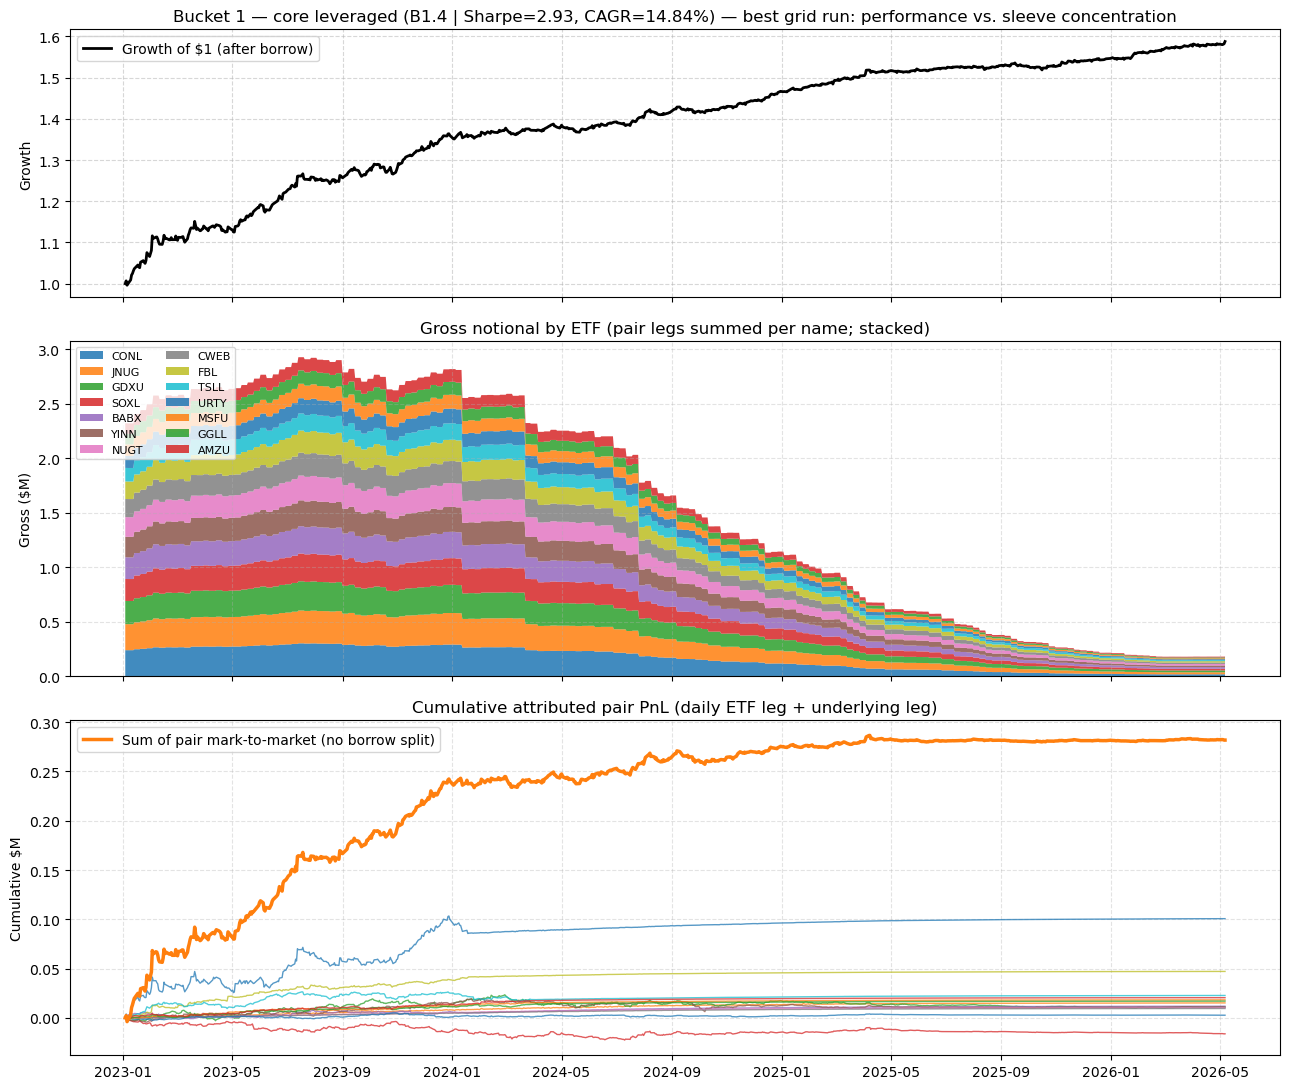

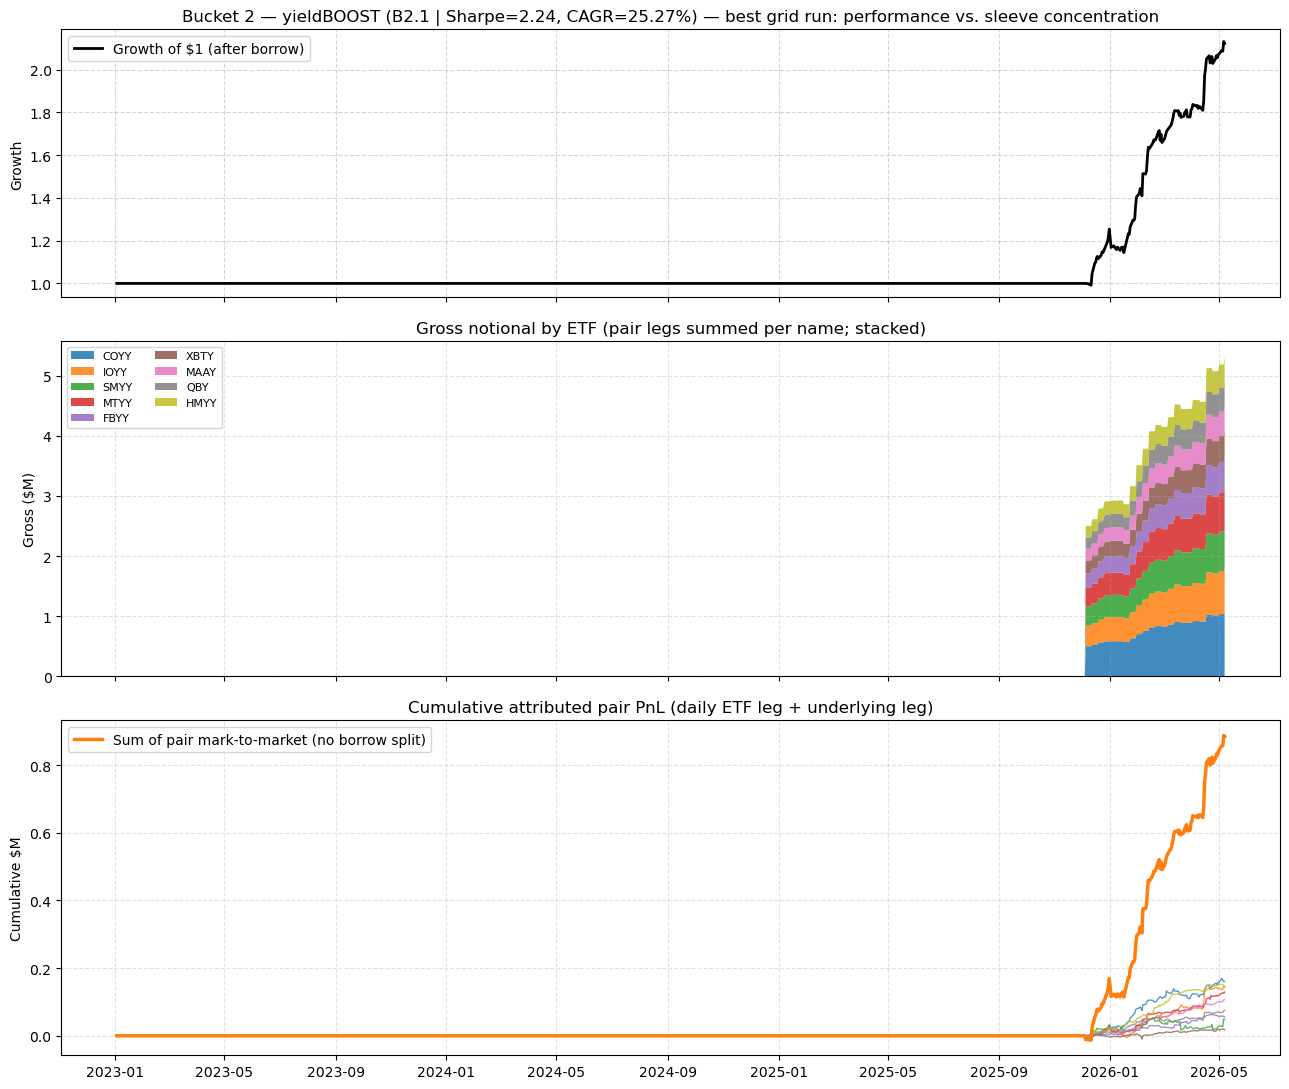

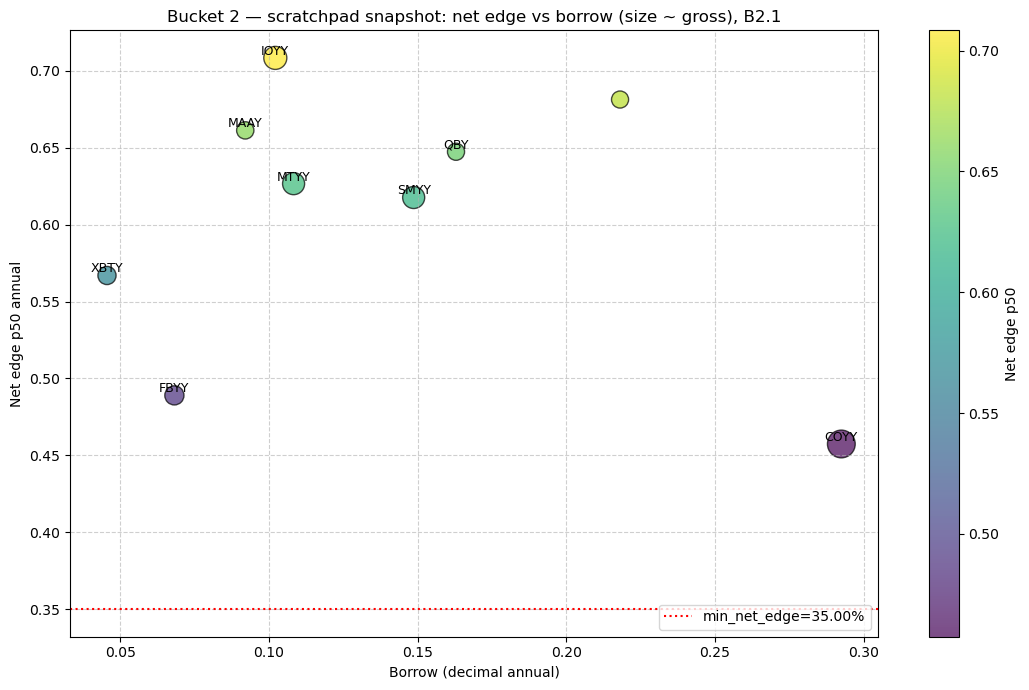

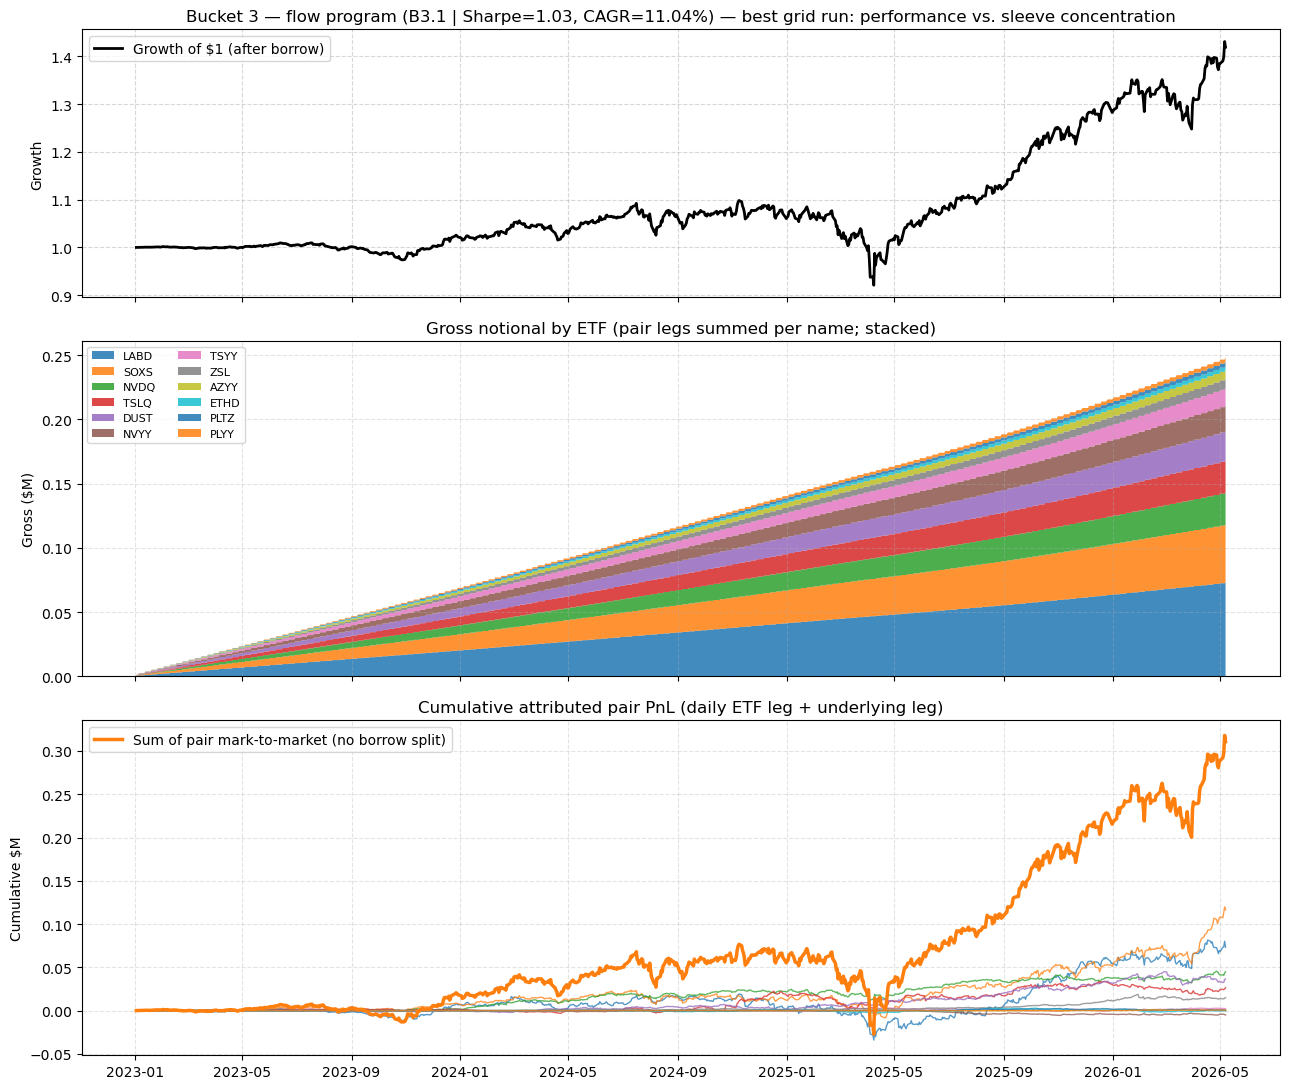

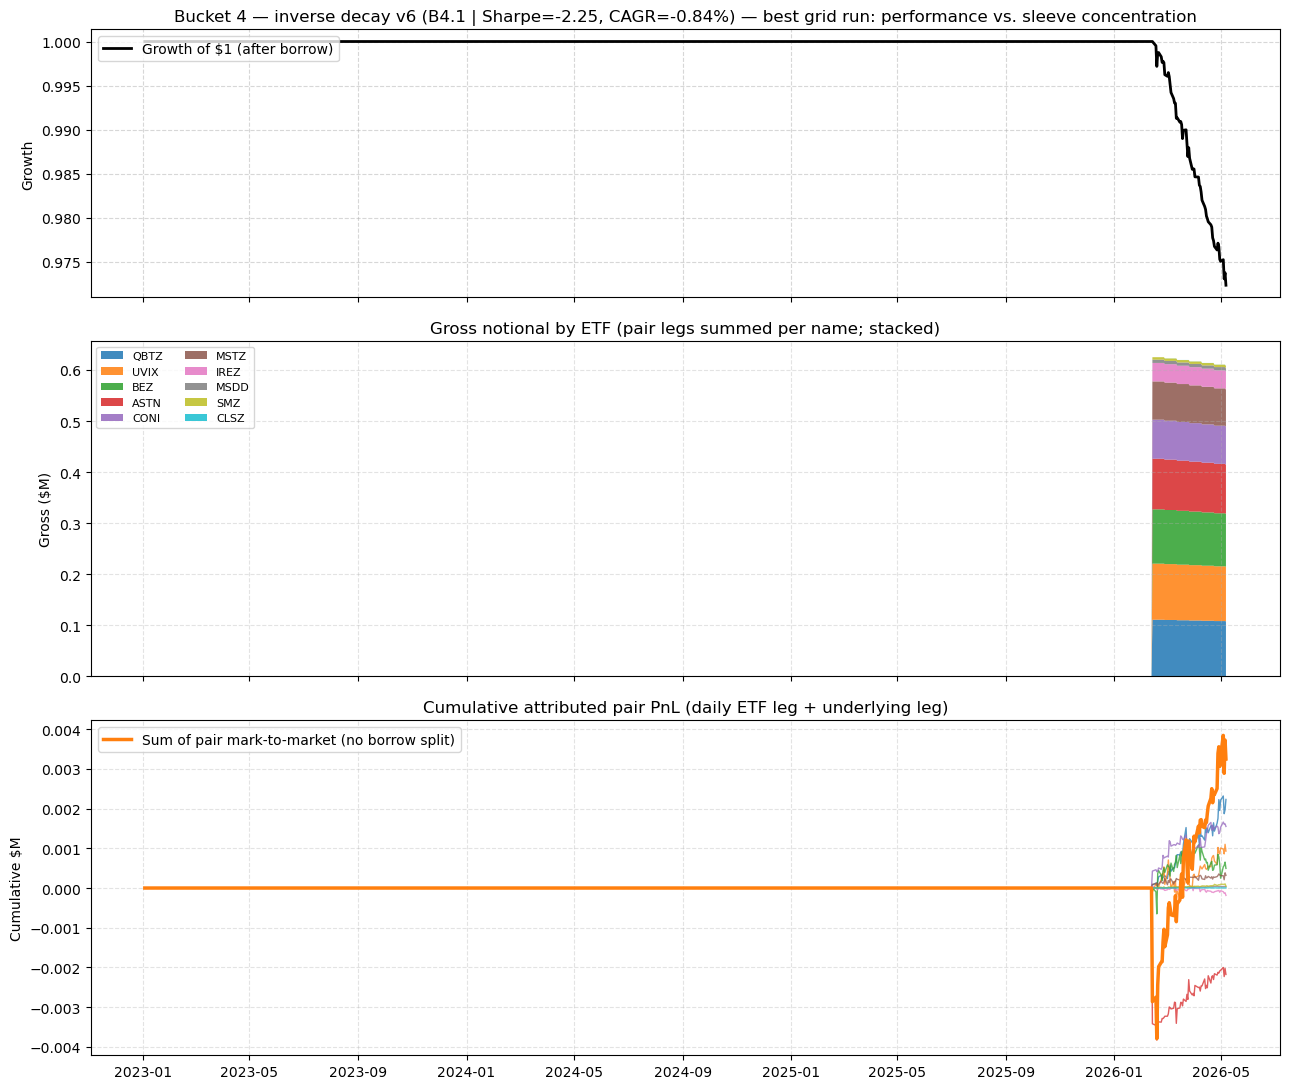

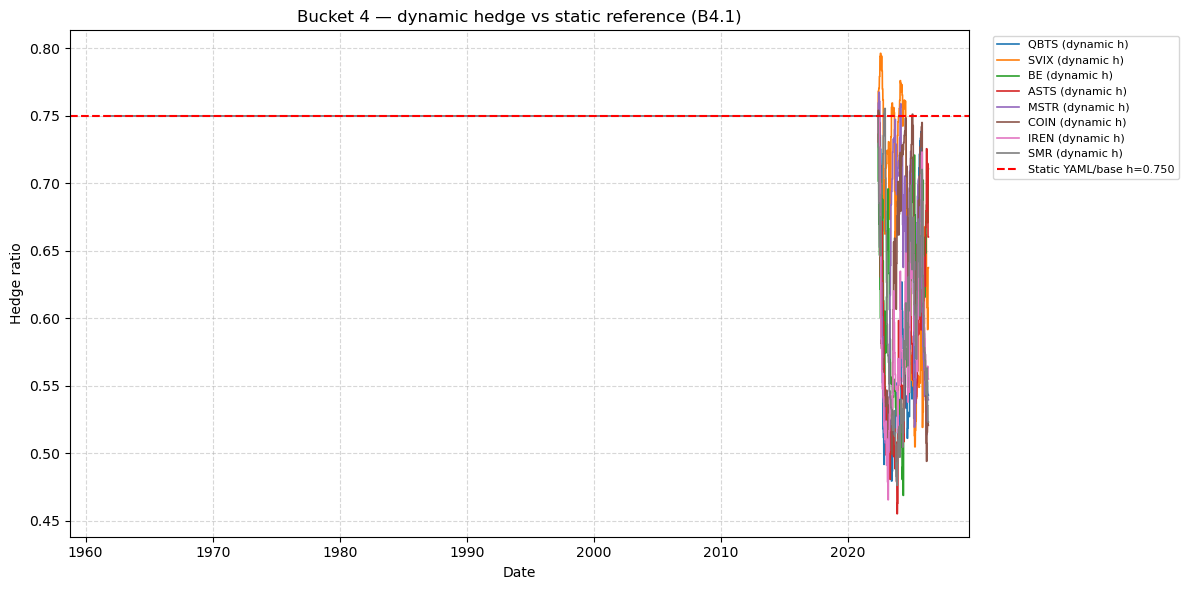

In [ ]:
def run_best_bucket_dashboard(
    bucket: int,
    *,
    title: str,
    results: pd.DataFrame,
    sized_by_label: dict[str, pd.DataFrame],
    grid: list[dict],
) -> None:
    if results is None or getattr(results, "empty", True) or bucket not in EXP.get("run_buckets", []):
        print(f"Skipping bucket {bucket} dashboard (not run or empty results).")
        return
    best_label = str(results.iloc[0]["label"])
    params = _params_for_run_label(best_label, grid)
    sized = sized_by_label.get(best_label) if bucket != 3 else None
    if bucket != 3 and (sized is None or sized.empty):
        print(f"No sized book for {best_label}.")
        return

    if bucket == 3:
        bt, meta, attr = simulate_bucket3(params, return_ticker_attribution=True)
    else:
        sleeve_gate = {}
        if bucket in SLEEVE_BY_BUCKET and SLEEVE_BY_BUCKET[bucket] in SLEEVE_START_MIN_ACTIVE_PAIRS:
            sleeve_gate[SLEEVE_BY_BUCKET[bucket]] = SLEEVE_START_MIN_ACTIVE_PAIRS[SLEEVE_BY_BUCKET[bucket]]
        _dash_b4dh = params.get("b4_dynamic_hedge")
        _dash_b4dh = bool(EXP.get("b4_dynamic_hedge", True)) if _dash_b4dh is None else bool(_dash_b4dh)
        _reb_sched = _resolve_sim_rebalance_freq(bucket=bucket, params=params)
        bt, meta, attr = simulate_sized_pairs(
            sized,
            label=BUCKET_LABEL[bucket],
            gross_leverage=float(params.get("gross_leverage", EXP["gross_leverage"])),
            min_active_pairs_by_sleeve=sleeve_gate or None,
            rebalance_freq=_reb_sched,
            return_pair_attribution=True,
            b4_dynamic_hedge=_dash_b4dh,
        )

    sub = f"{best_label} | Sharpe={float(results.iloc[0]['Sharpe']):.2f}, CAGR={float(results.iloc[0]['CAGR']):.2%}"
    plot_stacked_gross_and_cum_pnl_with_nav(
        bt,
        attr or {},
        title=f"{title} ({sub})",
        top_n=(None if bucket == 1 else 14),
    )

    if bucket == 2:
        plot_b2_sizing_diagnostics(sized, run_label=best_label, params=params)
    if bucket == 4:
        plot_b4_hedge_diagnostics(sized, run_label=best_label, b4_bt=bt)


run_best_bucket_dashboard(1, title="Bucket 1 — core leveraged", results=B1_RESULTS, sized_by_label=B1_SIZED, grid=GRID_B1)
run_best_bucket_dashboard(2, title="Bucket 2 — yieldBOOST", results=B2_RESULTS, sized_by_label=B2_SIZED, grid=GRID_B2)
run_best_bucket_dashboard(3, title="Bucket 3 — flow program", results=B3_RESULTS, sized_by_label=B3_SIZED, grid=GRID_B3)
run_best_bucket_dashboard(4, title="Bucket 4 — inverse decay v6", results=B4_RESULTS, sized_by_label=B4_SIZED, grid=GRID_B4)

